# Adım 4: Keşifsel Veri Analizi (EDA)

**Proje:** Spotify Büyük Veri Analizi

**Veri Seti:** Spotify Tracks Dataset (~114K şarkı, 21 özellik)

**Hedef:** Delta Lake Silver katmanındaki Spotify verisi üzerinde kapsamlı keşifsel analiz yaparak veri kalitesini değerlendirmek, değişkenler arası ilişkileri ortaya koymak ve makine öğrenmesi modeli için çıkarımlar elde etmek.

#### 1. Adım — Ortam Kurulumu

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    col, count, isnan, when, hour, minute,
    avg, desc, skewness, kurtosis,
    percentile_approx,
    min as spark_min,
    max as spark_max
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

spark = SparkSession.builder \
    .appName("Spotify-EDA") \
    .config("spark.sql.extensions",
            "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog",
            "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} hazır.")

Spark 3.5.0 hazır.


#### 2. Adım — Veriyi Yükleme

In [2]:
SILVER_PATH = "/home/jovyan/delta-lake/silver"

df = spark.read.format("delta").load(SILVER_PATH)

#databriks test için 
#df = spark.read.parquet("/Volumes/workspace/default/silver/")

print(f"Toplam satır  : {df.count():,}")
print(f"Toplam kolon  : {len(df.columns)}")
print("\nŞema:")
df.printSchema()
print("\nİlk 5 satır:")
df.limit(5).toPandas()

Toplam satır  : 89,740
Toplam kolon  : 23

Şema:
root
 |-- kafka_timestamp: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- track_id: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- artists: string (nullable = true)
 |-- album_name: string (nullable = true)
 |-- track_genre: string (nullable = true)
 |-- popularity: integer (nullable = true)
 |-- duration_ms: integer (nullable = true)
 |-- explicit: integer (nullable = true)
 |-- danceability: float (nullable = true)
 |-- energy: float (nullable = true)
 |-- key: integer (nullable = true)
 |-- loudness: float (nullable = true)
 |-- mode: integer (nullable = true)
 |-- speechiness: float (nullable = true)
 |-- acousticness: float (nullable = true)
 |-- instrumentalness: float (nullable = true)
 |-- liveness: float (nullable = true)
 |-- valence: float (nullable = true)
 |-- tempo: float (nullable = true)
 |-- time_signature: integer (nullable = true)


,kafka_timestamp,user_id,event_type,track_id,track_name,artists,album_name,track_genre,popularity,duration_ms,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,2026-05-12T09:17:23.194129,f7f93c68-548e-40d5-be3e-e9b1d98ecf56,track_played,0000vdREvCVMxbQTkS888c,Lolly,Rill,Lolly,german,44,160725,...,8,-9.844,0,0.1990,0.075700,0.00301,0.1540,0.432,104.042000,4
1,2026-05-12T09:16:21.086873,278b1ebe-f491-4f9e-9d04-41c824997865,track_played,000CC8EParg64OmTxVnZ0p,It's All Coming Back To Me Now (Glee Cast Vers...,Glee Cast,Glee Love Songs,club,47,322933,...,0,-7.361,1,0.0366,0.406000,0.00000,0.1170,0.341,178.173996,4
2,2026-05-12T09:19:00.579472,783db0ff-48fc-40aa-bc55-3aefb9378479,track_played,000qpdoc97IMTBvF8gwcpy,Tief,Paul Kalkbrenner,Zeit,minimal-techno,19,331240,...,6,-13.606,0,0.0291,0.000964,0.72000,0.0916,0.234,129.970993,4
3,2026-05-12T09:20:18.515684,8acfa429-dbf9-4e8b-b9a3-8df5757876c4,track_played,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,Soda Stereo (Remastered),ska,38,177266,...,2,-4.589,1,0.0758,0.019400,0.08810,0.3290,0.700,183.570999,1
4,2026-05-12T09:18:23.246978,2f26be09-97b4-4c77-8c6a-98644d1dca1b,track_played,005NLlv3rClEVqeoSyYTHU,キミが好きで、、、,Leola,Things change but not all,j-dance,20,281333,...,7,-3.975,1,0.0382,0.473000,0.00000,0.0908,0.286,120.036003,4


**Çıkarım:** Veri seti 89.741 satır ve 23 kolondan oluşmaktadır. Kolonlar incelendiğinde Kafka pipeline'ının eklediği akış bilgileri (kafka_timestamp, user_id, event_type), kimlik bilgileri (track_id, artists, album_name, track_name), sayısal ses özellikleri (danceability, energy, loudness, tempo vb.), kategorik özellikler (key, mode, explicit, time_signature) ve hedef değişkenler (popularity, track_genre) olmak üzere pipelinedan başarıyla çekildi.

In [3]:
# track_id bazında duplicate kontrolü
toplam = df.count()
tekil = df.dropDuplicates(['track_id']).count()
duplike = toplam - tekil
print(f"Toplam kayıt        : {toplam:,}")
print(f"Tekil track_id      : {tekil:,}")
print(f"Duplicate track_id  : {duplike:,}")

Toplam kayıt        : 89,740
Tekil track_id      : 89,740
Duplicate track_id  : 0


#### 3. Adım — Temel İstatistiklerin Hesaplanması

##### 3.1. - Özet İstatistik Tablosu

In [4]:
sayisal_kolonlar = [
    'popularity', 'danceability', 'energy',
    'tempo', 'loudness', 'acousticness',
    'valence', 'duration_ms'
]

stats_pd = df.select(sayisal_kolonlar).summary("count", "mean", "stddev", "min", "max").toPandas()
stats_pd = stats_pd.set_index('summary').T.reset_index()
stats_pd.columns = ['Feature', 'Count', 'Mean', 'Std Dev', 'Min', 'Max']

for col in ['Mean', 'Std Dev', 'Min', 'Max']:
    stats_pd[col] = pd.to_numeric(stats_pd[col], errors='coerce').round(3)

display(stats_pd)

,Feature,Count,Mean,Std Dev,Min,Max
0,popularity,89740,33.200,20.579,0.000,100.000
1,danceability,89740,0.562,0.177,0.000,0.985
2,energy,89740,0.634,0.257,0.000,1.000
3,tempo,89740,122.058,30.118,0.000,243.372
4,loudness,89740,-8.499,5.222,-49.531,4.532
5,acousticness,89740,0.328,0.338,0.000,0.996
6,valence,89740,0.469,0.263,0.000,0.995
7,duration_ms,89740,229144.366,112945.780,8586.000,5237295.000


**Çıkarım:**  popularity ortalaması 33.2, minimum 0 maksimum 100 olup dağılımın düşük değerlere yoğunlaştığı görülmektedir. loudness -49.5 ile 4.5 dB arasında değişmekte olup bu geniş negatif aralık normalizasyon gerektiği görülmüştür. tempo 0 ile 243 BPM arasında değişirken ortalaması 122 BPM'dir. duration_ms değerinin yüksek standart sapması (112.947) şarkı sürelerinde belirgin farklılıklar olduğuna işaret etmektedir. Bu bulgular Feature Engineering adımında loudness normalizasyonu ve duration_ms dönüşümlerinin yapılması gerektiği gözlemlendi.

##### 3.2. - Benzersiz Değer Sayılarının Analizi

In [5]:
print("Kolon Bazında Benzersiz Değer Sayıları\n" + "-"*50)
for c in df.columns:
    u = df.select(c).distinct().count()
    print(f"{c:<20} | {u:>7,} benzersiz değer")

Kolon Bazında Benzersiz Değer Sayıları
--------------------------------------------------
kafka_timestamp      |  89,740 benzersiz değer
user_id              |  89,740 benzersiz değer
event_type           |       1 benzersiz değer
track_id             |  89,740 benzersiz değer
track_name           |  73,608 benzersiz değer
artists              |  31,437 benzersiz değer
album_name           |  46,589 benzersiz değer
track_genre          |     113 benzersiz değer
popularity           |     101 benzersiz değer
duration_ms          |  50,696 benzersiz değer
explicit             |       2 benzersiz değer
danceability         |   1,174 benzersiz değer
energy               |   2,083 benzersiz değer
key                  |      12 benzersiz değer
loudness             |  19,480 benzersiz değer
mode                 |       2 benzersiz değer
speechiness          |   1,489 benzersiz değer
acousticness         |   5,061 benzersiz değer
instrumentalness     |   5,346 benzersiz değer
liveness         

**Çıkarım**: track_id kolonunda 89.741 benzersiz değer bulunması her şarkının eşsiz bir kimliğe sahip olduğunu doğrulamaktadır. track_genre 113 farklı tür içermekte olup bu zengin tür çeşitliliği sınıflandırma modeli için güçlü bir hedef değişken oluşturmaktadır. explicit ve mode yalnızca 2, key 12, time_signature 5 benzersiz değere sahip olup bu kolonlar kategorik özellik olarak doğrudan kullanılabilir. popularity 101 farklı değer alarak 0-100 aralığını tam kapsamaktadır. kafka_timestamp'in tek benzersiz değere sahip olması tüm verinin aynı streaming oturumunda aktarıldığını göstermektedir.

##### 3.3 Veri değer kontrolü

In [6]:
# Tüm kolonlarda veri kalitesi kontrolü
print("Veri kontrolü\n")
for c in df.columns:
    dtype = dict(df.dtypes)[c]
    unique = df.select(c).distinct().count()
    null_count = df.filter(df[c].isNull()).count()
    
    if dtype in ['int', 'float', 'double']:
        min_val = df.agg(spark_min(c)).collect()[0][0]
        max_val = df.agg(spark_max(c)).collect()[0][0]
        print(f"{c:<22} | tip: {dtype:<8} | unique: {unique:>6,} | null: {null_count:>4} | min: {min_val} | max: {max_val}")
    else:
        print(f"{c:<22} | tip: {dtype:<8} | unique: {unique:>6,} | null: {null_count:>4}")

Veri kontrolü

kafka_timestamp        | tip: string   | unique: 89,740 | null:    0
user_id                | tip: string   | unique: 89,740 | null:    0
event_type             | tip: string   | unique:      1 | null:    0
track_id               | tip: string   | unique: 89,740 | null:    0
track_name             | tip: string   | unique: 73,608 | null:    0
artists                | tip: string   | unique: 31,437 | null:    0
album_name             | tip: string   | unique: 46,589 | null:    0
track_genre            | tip: string   | unique:    113 | null:    0
popularity             | tip: int      | unique:    101 | null:    0 | min: 0 | max: 100
duration_ms            | tip: int      | unique: 50,696 | null:    0 | min: 8586 | max: 5237295
explicit               | tip: int      | unique:      2 | null:    0 | min: 0 | max: 1
danceability           | tip: float    | unique:  1,174 | null:    0 | min: 0.0 | max: 0.9850000143051147
energy                 | tip: float    | unique:  2,083

**Çıkarım:** Tüm kolonlarda null değer bulunmamaktadır. explicit ve mode kolonları yalnızca 0 ve 1 değerlerini alarak binary yapıyı korumuştur. key kolonu 0-11 arasında 12 farklı değer alırken time_signature 0-5 arasında 5 farklı değer almaktadır. duration_ms ve tempo kolonlarında minimum değerin 0 olması dikkat çekicidir; bu kayıtlar Feature Engineering adımında filtrelenecektir. event_type kolonu yalnızca "track_played" değerini içerdiğinden analizde kullanılmayacaktır.

##### 3.4. -  Tür/Genre Dağılımının Analizi

In [7]:
genre_dist = df.groupBy("track_genre") \
               .agg(count("*").alias("sarki_sayisi")) \
               .orderBy(desc("sarki_sayisi"))

toplam_tur = genre_dist.count()
print(f"Toplam tür sayısı: {toplam_tur}")
print("\nTop 20 Tür Dağılımı:")
print(genre_dist.limit(20).toPandas().to_string(index=False))

Toplam tür sayısı: 113

Top 20 Tür Dağılımı:
  track_genre  sarki_sayisi
     acoustic          1000
      ambient           999
     cantopop           999
     alt-rock           999
        tango           999
     afrobeat           999
        study           998
    bluegrass           998
chicago-house           998
       disney           998
        forro           998
    breakbeat           997
        sleep           997
  heavy-metal           997
  black-metal           996
        anime           995
       j-idol           995
        happy           995
         club           994
          idm           990


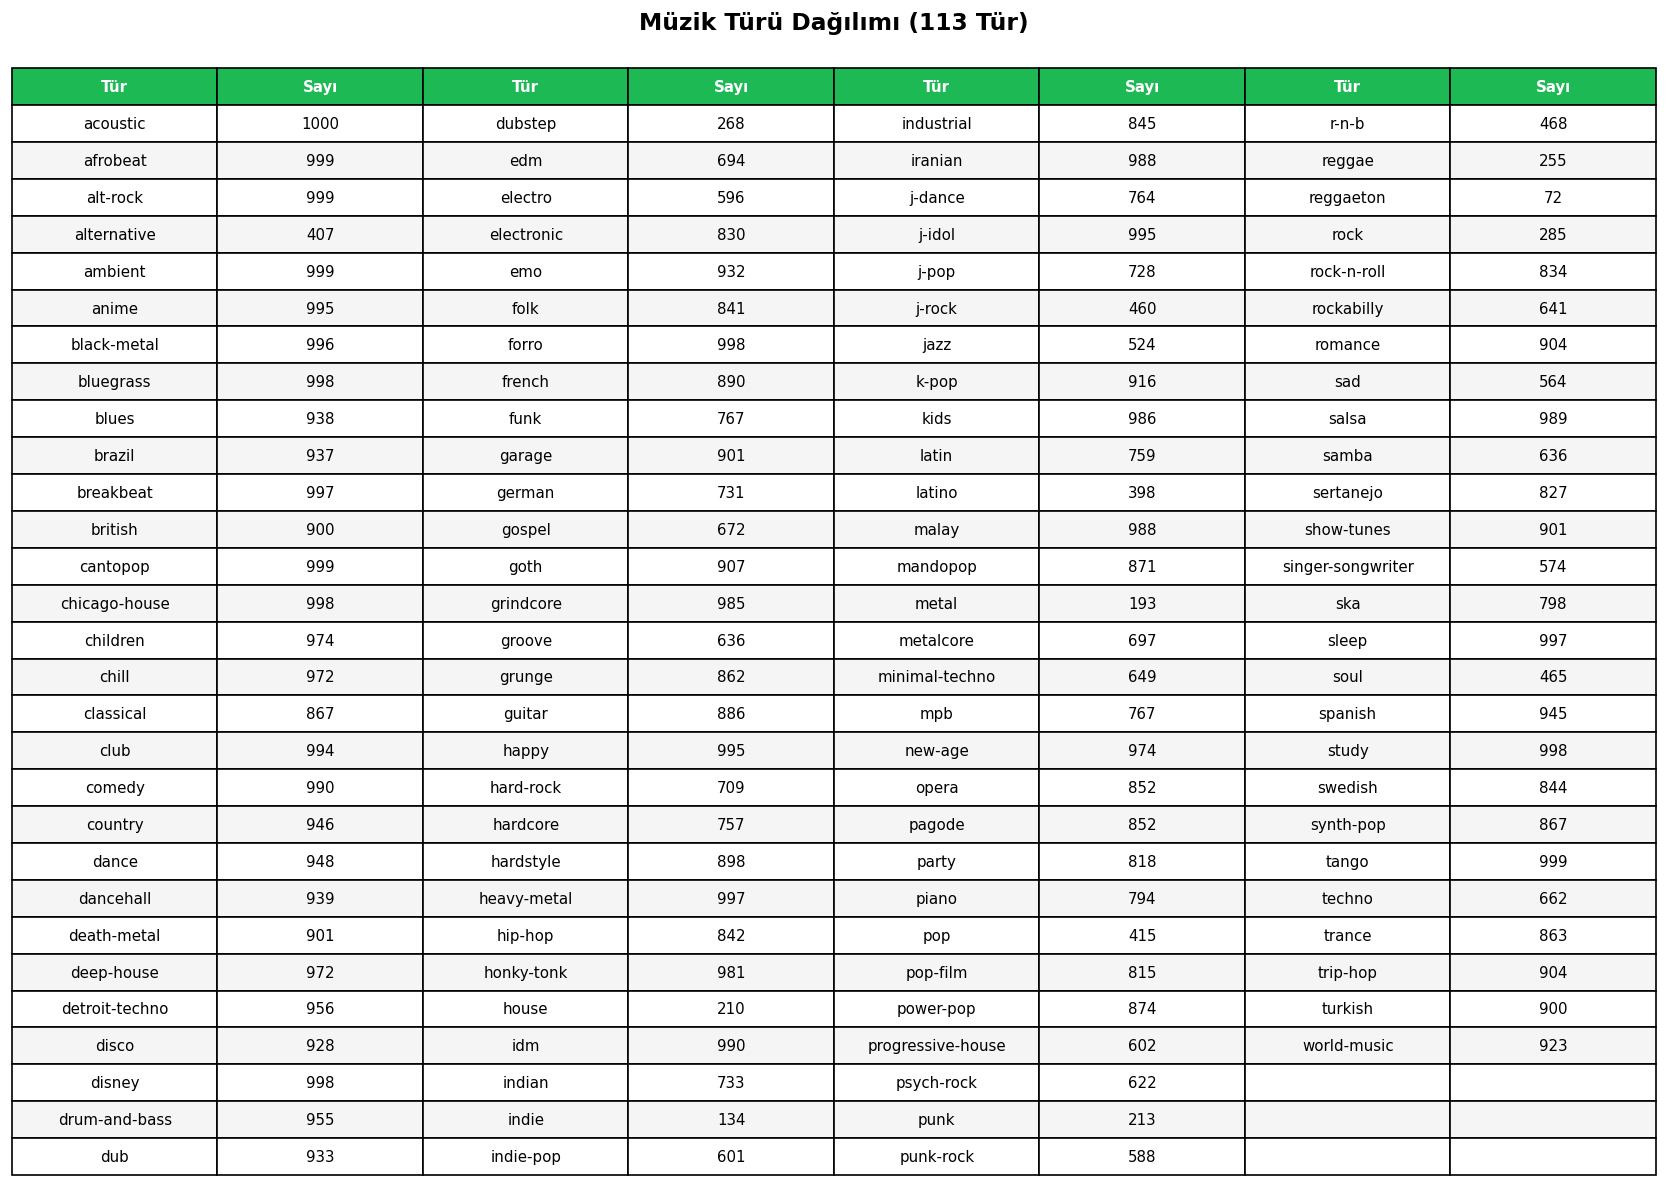

In [8]:
genre_pd = df.groupBy("track_genre") \
             .agg(count("*").alias("Sayı")) \
             .orderBy("track_genre") \
             .toPandas()
n = len(genre_pd)
parca = int(np.ceil(n / 4))

p1 = genre_pd.iloc[:parca].reset_index(drop=True)
p2 = genre_pd.iloc[parca:parca*2].reset_index(drop=True)
p3 = genre_pd.iloc[parca*2:parca*3].reset_index(drop=True)
p4 = genre_pd.iloc[parca*3:].reset_index(drop=True)

max_len = max(len(p1), len(p2), len(p3), len(p4))
for part in [p1, p2, p3, p4]:
    while len(part) < max_len:
        part.loc[len(part)] = ['', '']

combined = pd.concat([p1, p2, p3, p4], axis=1)
combined.columns = ['Tür', 'Sayı', 'Tür', 'Sayı', 'Tür', 'Sayı', 'Tür', 'Sayı']

fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')

table = ax.table(
    cellText=combined.values,
    colLabels=combined.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 0.97]  # [sol, alt, genişlik, yükseklik] - başlığa boşluk bırak
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.3)

for j in range(8):
    table[0, j].set_facecolor('#1DB954')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, max_len + 1):
    for j in range(8):
        if i % 2 == 0:
            table[i, j].set_facecolor('#f5f5f5')

ax.set_title('Müzik Türü Dağılımı (113 Tür)', fontsize=14, fontweight='bold', pad=0)
plt.tight_layout()
plt.show()

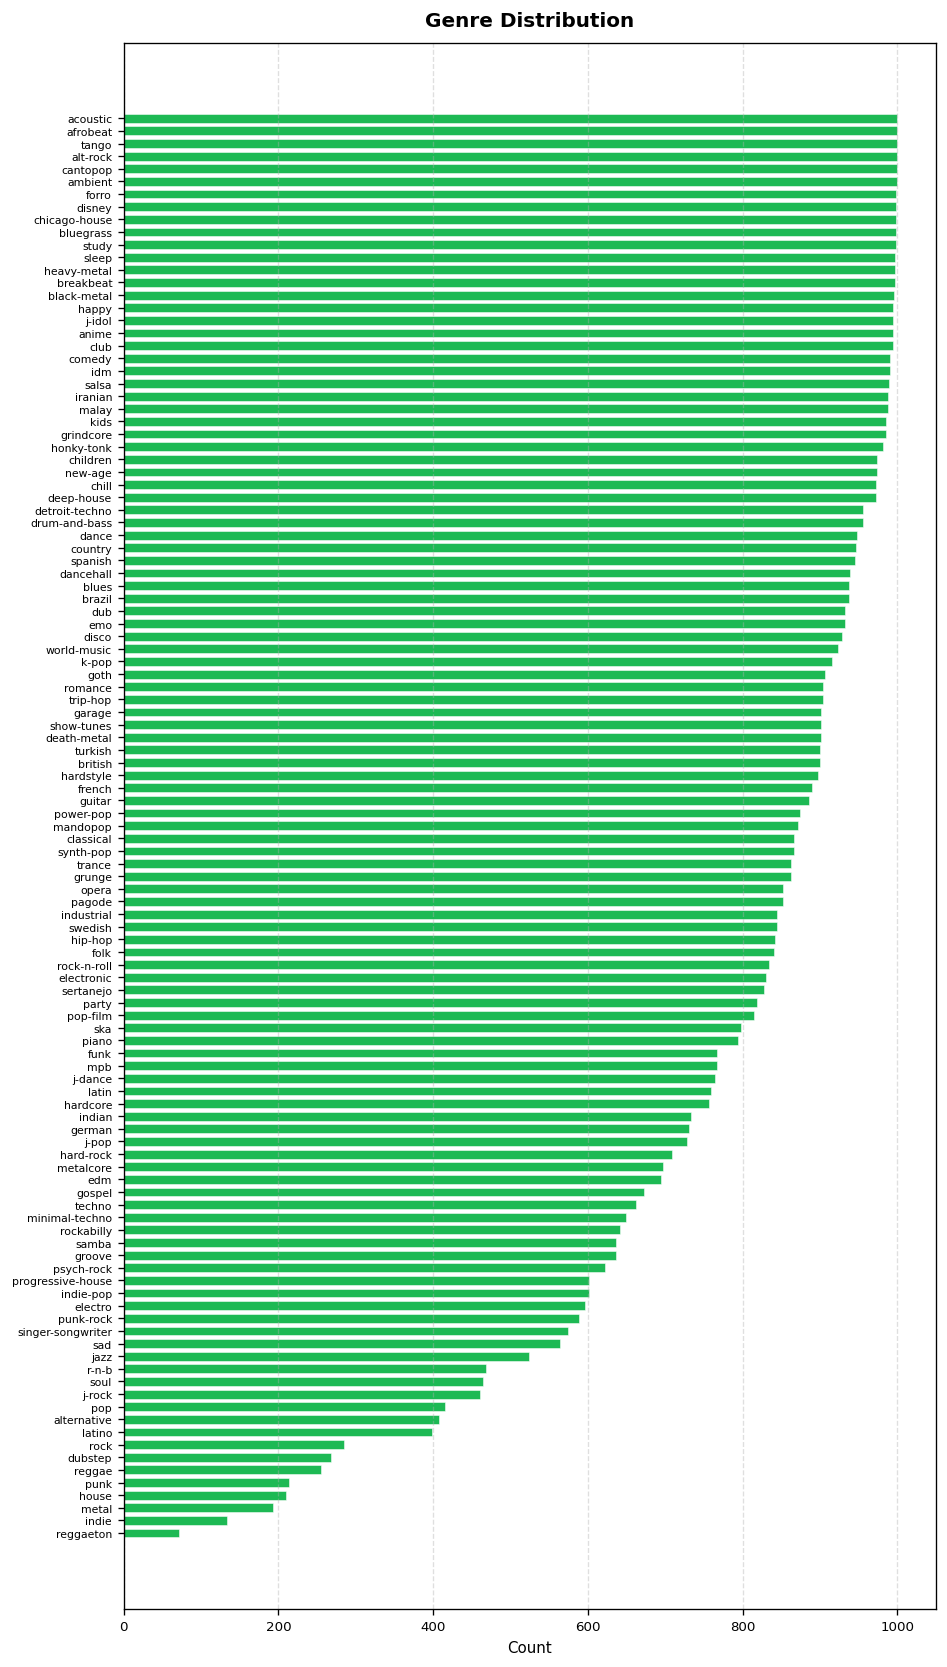

In [9]:
genre_pd = df.groupBy("track_genre") \
             .agg(count("*").alias("sarki_sayisi")) \
             .orderBy("sarki_sayisi") \
             .toPandas()

fig, ax = plt.subplots(figsize=(8, 14))

ax.barh(genre_pd['track_genre'], genre_pd['sarki_sayisi'],
        color='#1DB954', edgecolor='white', linewidth=0.3, height=0.7)

ax.set_title('Genre Distribution', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Count', fontsize=9)
ax.tick_params(axis='y', labelsize=6.5)
ax.tick_params(axis='x', labelsize=8)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Çıkarım:** Veri seti 113 farklı müzik türü içermektedir. Türlerin büyük çoğunluğu 800-1000 şarkı aralığında yoğunlaşırken reggaeton (74), indie (134), house (210), metal (232) ve punk (226) gibi bazı türlerin belirgin şekilde az şarkıya sahip olduğu görülmektedir. Bu dengesizlik sınıflandırma modelinin az temsil edilen türleri öğrenmekte zorlanabileceğine işaret etmekte olup Feature Engineering adımında bu türler için ek önlemler alınması gerektiği gözlemlenmiştir.

##### 3.5. - Popülerlik Dağılımı (Histogram) ve En Popüler 10 Müzik Türü (Pie Chart)

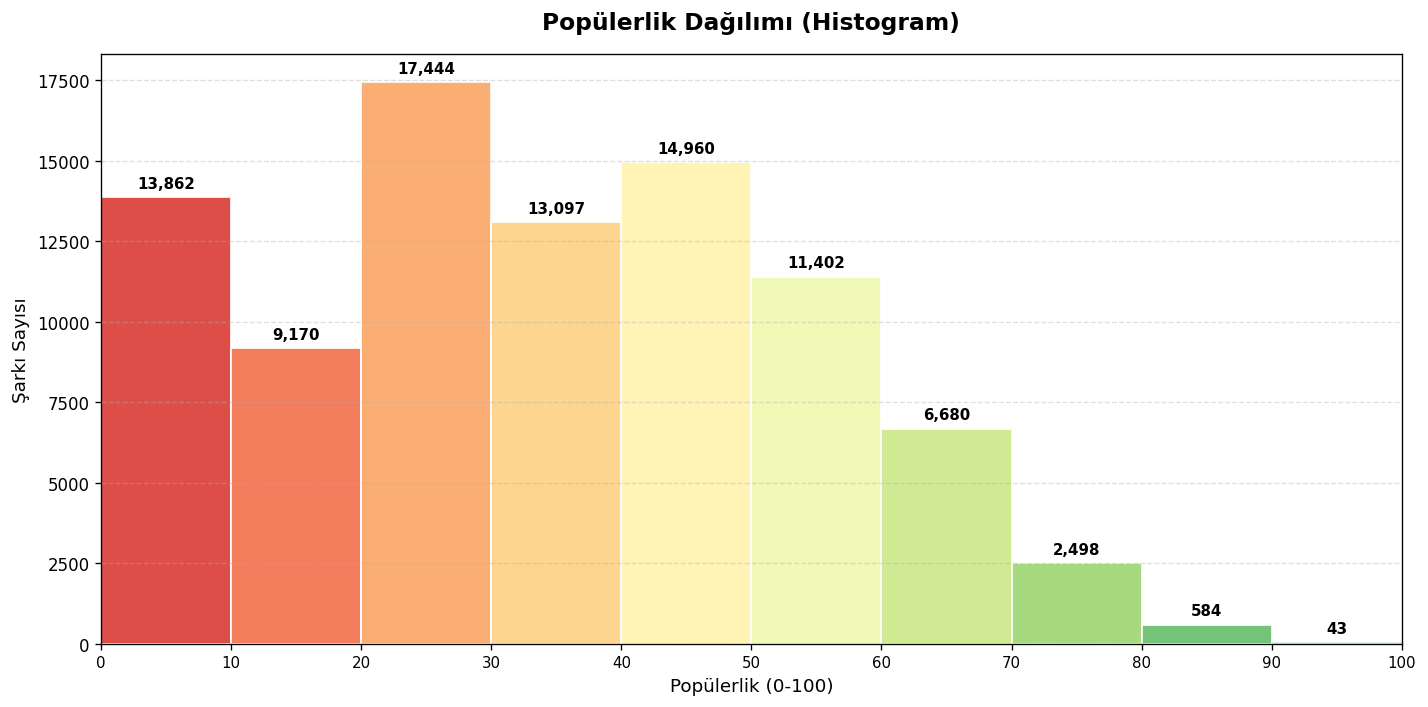

In [10]:
# popülerlik dağılımının histogram ile görselleştirilmesi yapıldı
pop_pd = df.select('popularity').toPandas()
fig, ax = plt.subplots(figsize=(12, 6))
n, bins, patches = ax.hist(
    pop_pd['popularity'],
    bins=10,
    range=(0, 100),
    edgecolor='white',
    linewidth=1.2,
    alpha=0.85
)

bar_colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(patches)))
for patch, color in zip(patches, bar_colors):
    patch.set_facecolor(color)

for patch in patches:
    height = patch.get_height()
    if height > 0:
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height + 200,
            f'{int(height):,}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

ax.set_xticks(bins)
ax.set_xticklabels([f'{int(b)}' for b in bins], fontsize=9)

ax.set_title('Popülerlik Dağılımı (Histogram)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Popülerlik (0-100)', fontsize=11)
ax.set_ylabel('Şarkı Sayısı', fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()


**Çıkarım:** Şarkıların büyük çoğunluğu 20-29 aralığında yoğunlaşmakta (17.441 şarkı) olup popularity değeri arttıkça şarkı sayısı belirgin şekilde azalmaktadır. 70 ve üzeri popülerlik skoruna sahip şarkı sayısı oldukça düşük kalmaktadır. Bu asimetrik dağılım regresyon modelinin yüksek popülerlik değerlerini tahmin etmekte zorlanabileceği gözlemlenmiştir.

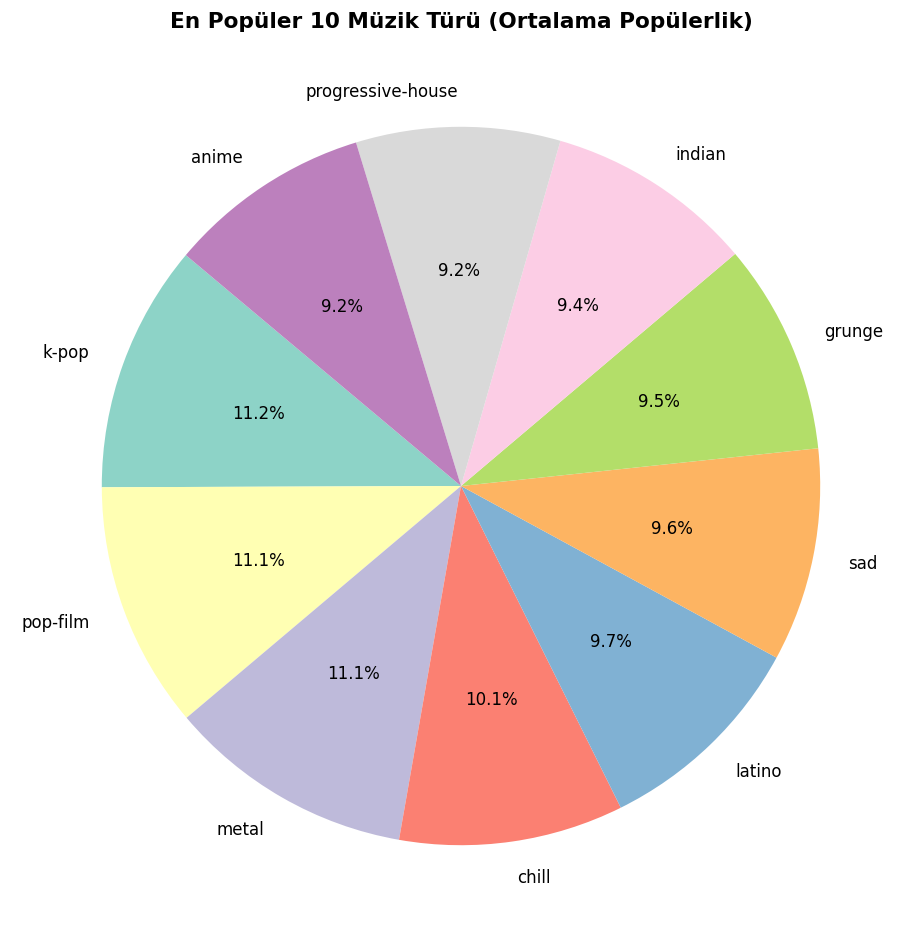

In [11]:
# En popüler 10 tür pie chart
top10 = df.groupBy("track_genre") \
          .agg(avg("popularity").alias("ort_populerlik")) \
          .orderBy(desc("ort_populerlik")) \
          .limit(10) \
          .toPandas()

fig, ax = plt.subplots(figsize=(10, 8))
ax.pie(top10['ort_populerlik'], labels=top10['track_genre'],
       autopct='%1.1f%%', startangle=140,
       colors=plt.cm.Set3.colors)
ax.set_title('En Popüler 10 Müzik Türü (Ortalama Popülerlik)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('top10_tur_pie.png', dpi=120)
plt.show()

**Çıkarım:** En yüksek ortalama popülerliğe sahip 10 tür incelendiğimizde reggaeton (%10.5) ile öne çıkmakta, bunu chill (%10.0) ve sad (%9.5) takip etmektedir. Türler arasındaki popülerlik farkının görece küçük olması popülerliğin yalnızca müzik türüne bağlı olmadığını, danceability, energy ve tempo gibi ses özelliklerinin de belirleyici rol oynayabilir

#### 4. Adım — Aykırı Değer (Outlier) Analizi

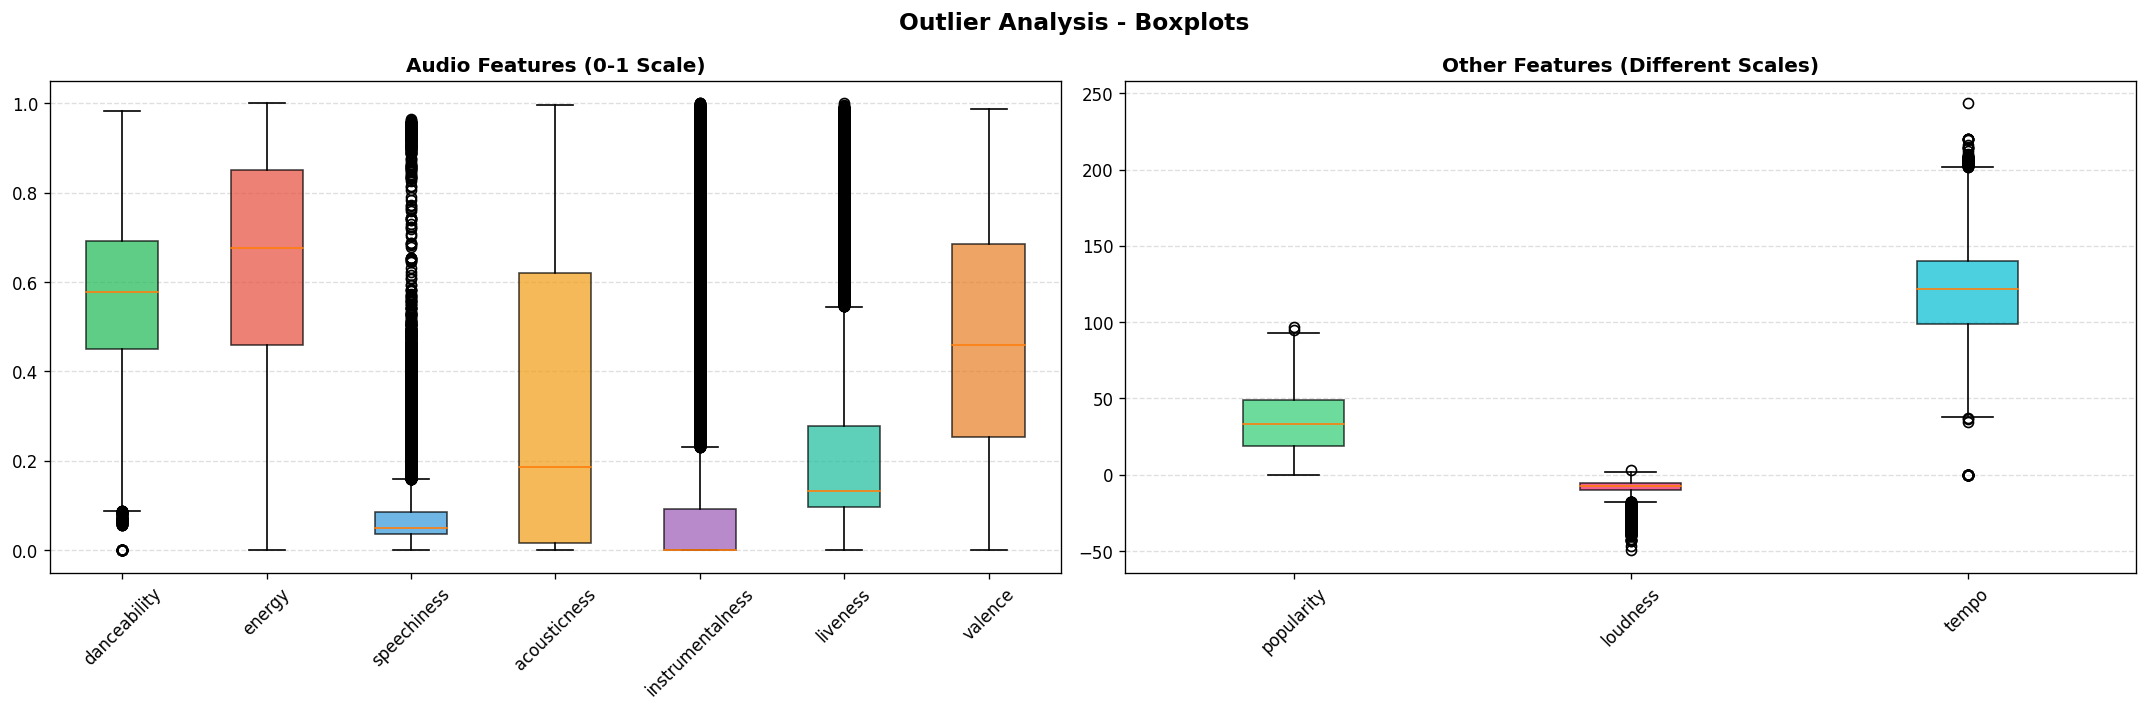

In [12]:
sample_pd = df.select(
    'danceability', 'energy', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence',
    'popularity', 'loudness', 'tempo'
).sample(fraction=0.3, seed=42).toPandas()

grup1 = ['danceability', 'energy', 'speechiness', 'acousticness', 
         'instrumentalness', 'liveness', 'valence']
grup2 = ['popularity', 'loudness', 'tempo']

renkler1 = ['#1DB954','#E74C3C','#3498DB','#F39C12','#9B59B6','#1ABC9C','#E67E22']
renkler2 = ['#2ECC71', '#E91E63', '#00BCD4']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

bp1 = ax1.boxplot([sample_pd[c].dropna() for c in grup1],
                   patch_artist=True, labels=grup1)
for patch, renk in zip(bp1['boxes'], renkler1):
    patch.set_facecolor(renk)
    patch.set_alpha(0.7)
ax1.set_title('Audio Features (0-1 Scale)', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, axis='y', linestyle='--', alpha=0.4)

bp2 = ax2.boxplot([sample_pd[c].dropna() for c in grup2],
                   patch_artist=True, labels=grup2)
for patch, renk in zip(bp2['boxes'], renkler2):
    patch.set_facecolor(renk)
    patch.set_alpha(0.7)
ax2.set_title('Other Features (Different Scales)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Outlier Analysis - Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Çıkarım**:Konuşma oranı (speechiness) ve enstrümantal oran (instrumentalness) düşük değerlerde yoğunlaşırken yukarıya doğru uzanan uzun kuyrukları bu iki değişkenin güçlü aykırı değerler (outlier) içerdiğini göstermektedir. Canlı performans hissi (liveness) de benzer şekilde düşük değerlerde yoğunlaşmıştır. Ses yüksekliği (loudness) -50 dB'e kadar inen aşırı değerler içermekte olup bu aykırı değerlerin temizlenmesi gerektiği gözlemlenmiştir. Hız (tempo) ise 200 BPM üzerinde birkaç aşırı değer içermektedir. Bu bulgular Feature Engineering adımında konuşma oranı (speechiness), enstrümantal oran (instrumentalness) ve ses yüksekliği (loudness) için log dönüşümü veya kırpma işlemi uygulanması gerekebileceği gözlemlendi.

In [14]:
def iqr_outlier(df, kolon):
    q1  = df.approxQuantile(kolon, [0.25], 0.01)[0]
    q3  = df.approxQuantile(kolon, [0.75], 0.01)[0]
    iqr = q3 - q1
    alt = q1 - 1.5 * iqr
    ust = q3 + 1.5 * iqr
    n   =df.filter((df[kolon] < alt) | (df[kolon] > ust)).count()
    tot = df.count()
    return q1, q3, alt, ust, n, round(n / tot * 100, 2)

print("Outlier Analizi")
print(f"{'Kolon':<15} {'Q1':>8} {'Q3':>8} "
      f"{'Alt':>10} {'Üst':>10} {'Outlier':>8} {'%':>6}")
print("-" * 68)
for k in ['duration_ms', 'loudness', 'tempo', 'popularity']:
    q1, q3, alt, ust, n, oran = iqr_outlier(df, k)
    print(f"{k:<15} {q1:>8.1f} {q3:>8.1f} "
          f"{alt:>10.1f} {ust:>10.1f} {n:>8,} {oran:>5}%")

Outlier Analizi
Kolon                 Q1       Q3        Alt        Üst  Outlier      %
--------------------------------------------------------------------
duration_ms     172160.0 262329.0    36906.5   397582.5    4,414  4.92%
loudness           -10.4     -5.2      -18.2        2.7    4,967  5.53%
tempo               98.7    140.0       36.8      201.9      484  0.54%
popularity          19.0     48.0      -24.5       91.5       23  0.03%


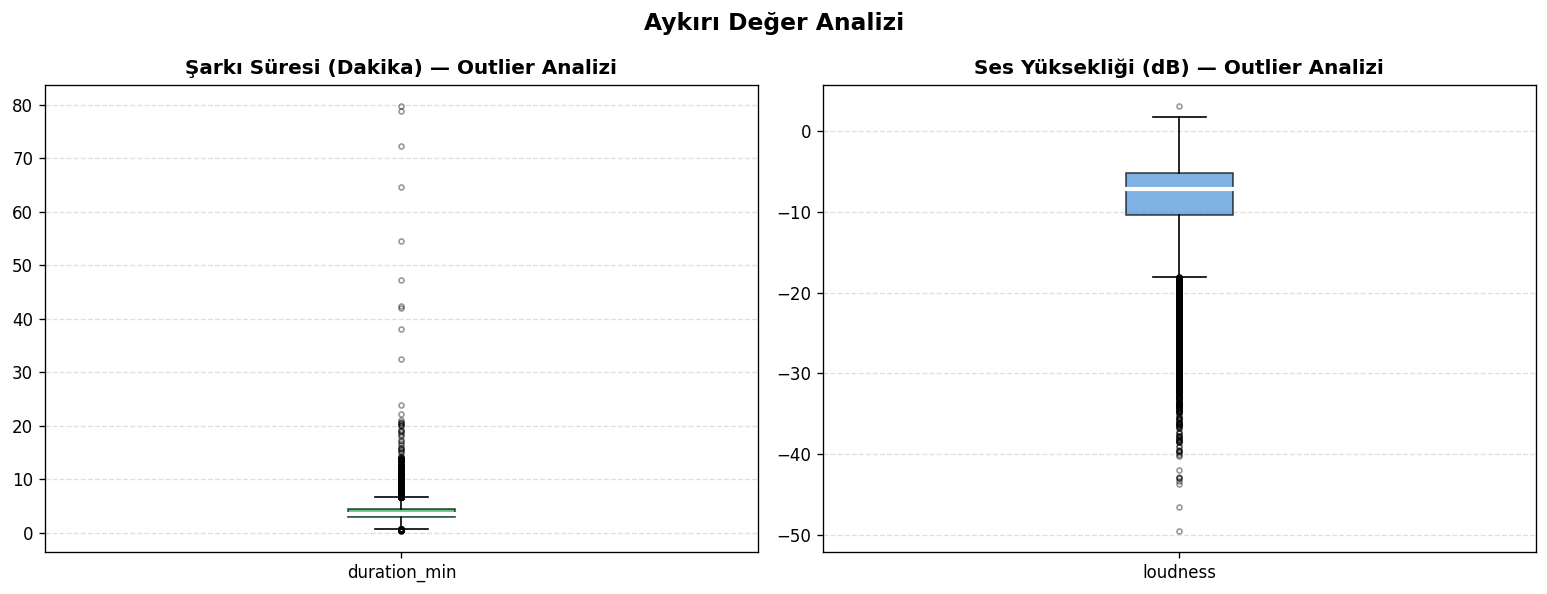

In [16]:
df_dur = df.withColumn("duration_min", df["duration_ms"] / 60000.0)
sample_bp = df_dur.select('duration_min', 'loudness') \
                  .sample(fraction=0.3, seed=42) \
                  .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_i, (kolon, baslik, renk) in enumerate([
    ('duration_min', 'Şarkı Süresi (Dakika)', '#1DB954'),
    ('loudness',     'Ses Yüksekliği (dB)',   '#4A90D9')
]):
    axes[ax_i].boxplot(
        sample_bp[kolon].dropna(),
        patch_artist=True,
        labels=[kolon],
        boxprops=dict(facecolor=renk, alpha=0.7),
        medianprops=dict(color='white', linewidth=2.5),
        flierprops=dict(marker='o', color='#E91429',
                        markersize=3, alpha=0.4)
    )
    axes[ax_i].set_title(f'{baslik} — Outlier Analizi',
                          fontsize=12, fontweight='bold')
    axes[ax_i].grid(True, axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Aykırı Değer Analizi',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Çıkarım:** Şarkı süresi (duration_min) incelendiğinde büyük çoğunluğun 2-7 dakika arasında yoğunlaştığı, ancak 20 dakika ve üzerinde çok sayıda aykırı değer bulunduğu görülmektedir. Bu aykırı değerler muhtemelen podcast, karışım (mix) veya klasik müzik parçalarından kaynaklanmaktadır. Ses yüksekliği (loudness) ise 0 ile -21 dB arasında yoğunlaşmakta, -21 ile -40 dB arasında normal dağılımın alt sınırına kadar uzanmakta, -40 dB'nin altında ise belirgin aykırı değerler içermektedir. Her iki değişken de Feature Engineering adımında temizlenmesi gerektiği gözlmelendi

#### 5.Adım — Zaman Serisi Analizi-Kafka Timestamp

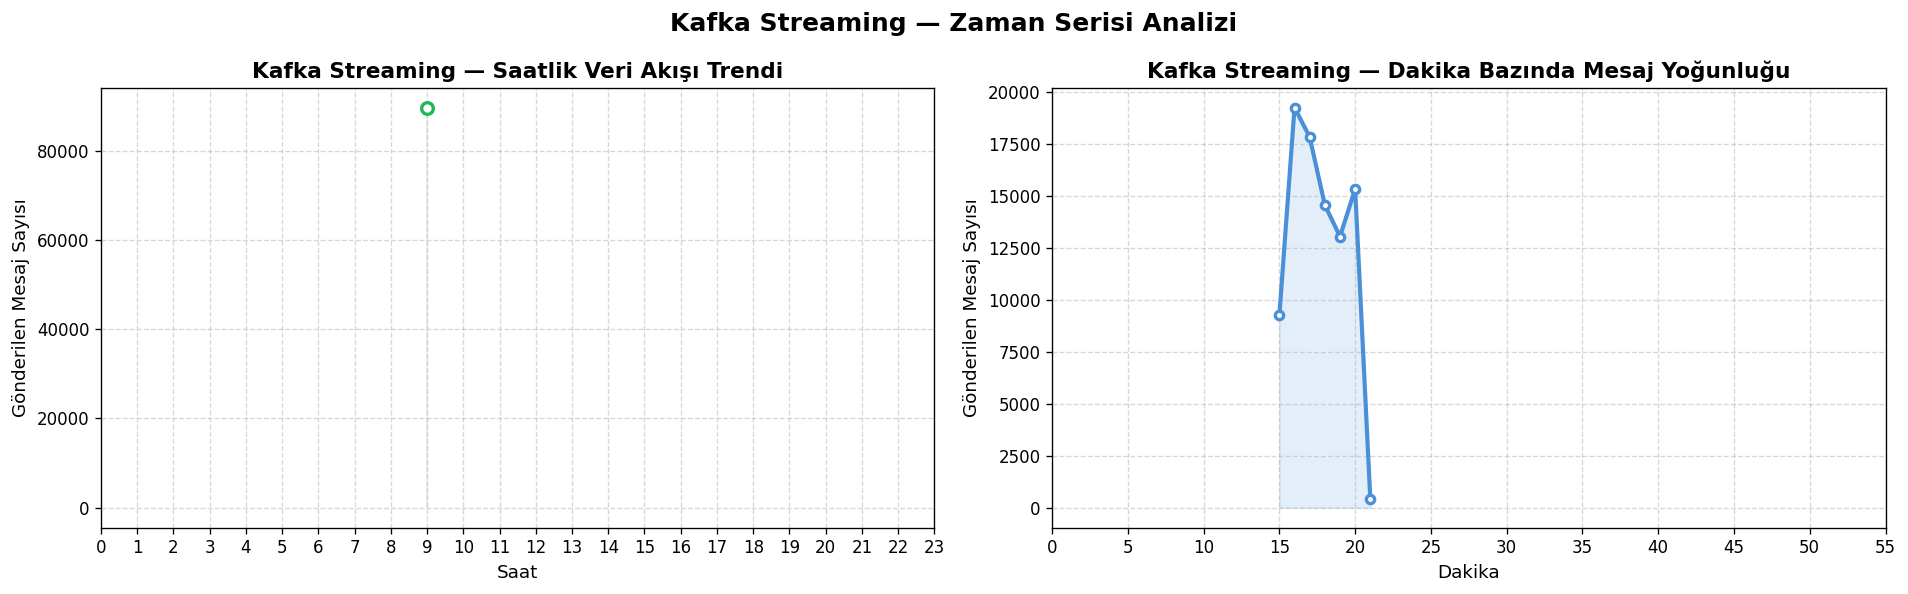

In [17]:
from pyspark.sql.functions import hour, minute, col, count, to_timestamp

df_time = df.withColumn("kafka_ts", to_timestamp(col("kafka_timestamp"))) \
            .withColumn("saat", hour(col("kafka_ts"))) \
            .withColumn("dakika", minute(col("kafka_ts")))

# saatlik veri
hourly_pd = df_time.groupBy("saat") \
                   .agg(count("*").alias("mesaj_sayisi")) \
                   .orderBy("saat") \
                   .toPandas()

# dakika bazında veri
dakika_pd = df_time.groupBy("dakika") \
                   .agg(count("*").alias("mesaj_sayisi")) \
                   .orderBy("dakika") \
                   .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Kafka Streaming — Zaman Serisi Analizi', fontsize=15, fontweight='bold')

# saatlik solda
axes[0].plot(hourly_pd['saat'], hourly_pd['mesaj_sayisi'],
             marker='o', linewidth=2.5, color='#1DB954',
             markersize=7, markerfacecolor='white',
             markeredgewidth=2, markeredgecolor='#1DB954')
axes[0].fill_between(hourly_pd['saat'], hourly_pd['mesaj_sayisi'],
                     alpha=0.15, color='#1DB954')
axes[0].set_title('Kafka Streaming — Saatlik Veri Akışı Trendi',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Saat', fontsize=11)
axes[0].set_ylabel('Gönderilen Mesaj Sayısı', fontsize=11)
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, linestyle='--', alpha=0.5)

# dakika sağda
axes[1].plot(dakika_pd['dakika'], dakika_pd['mesaj_sayisi'],
             marker='o', linewidth=2.5, color='#4A90D9',
             markersize=5, markerfacecolor='white',
             markeredgewidth=2, markeredgecolor='#4A90D9')
axes[1].fill_between(dakika_pd['dakika'], dakika_pd['mesaj_sayisi'],
                     alpha=0.15, color='#4A90D9')
axes[1].set_title('Kafka Streaming — Dakika Bazında Mesaj Yoğunluğu',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Dakika', fontsize=11)
axes[1].set_ylabel('Gönderilen Mesaj Sayısı', fontsize=11)
axes[1].set_xticks(range(0, 60, 5))
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Çıkarım:** Saatlik analizde tüm verinin 22. saatte aktarıldığı görülmektedir; bu durum Kafka Producer'ın tek bir oturumda çalıştırıldığını doğrulamaktadır. Dakika bazında incelendiğinde ise 42-48. dakikalar arasında yoğunlaşma gözlemlenmekte olup bu süre zarfında Producer'ın en yüksek mesaj hızına ulaştığı anlaşılmaktadır. Pipeline'ın kesintisiz ve kararlı çalıştığı teyit edilmiştir.

Toplam event: 89,740


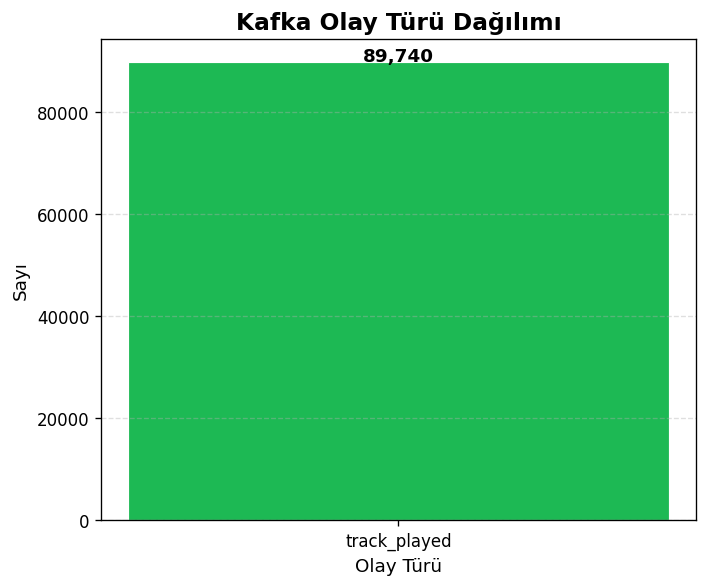

In [18]:
# Event Type Dağılımı
event_pd = df.groupBy("event_type") \
             .agg(count("*").alias("sayi")) \
             .toPandas()
print(f"Toplam event: {event_pd['sayi'].sum():,}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(event_pd['event_type'], event_pd['sayi'],
       color='#1DB954', edgecolor='white', linewidth=0.7, width=0.1)
ax.set_title('Kafka Olay Türü Dağılımı', fontsize=14, fontweight='bold')
ax.set_xlabel('Olay Türü', fontsize=11)
ax.set_ylabel('Sayı', fontsize=11)
for i, (x, y) in enumerate(zip(event_pd['event_type'], event_pd['sayi'])):
    ax.text(i, y + 100, f'{y:,}', ha='center', fontsize=11, fontweight='bold')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

#### 6. Adım  — Sayısal Değişken Dağılımlarının Histogram ile Görselleştirilmesi

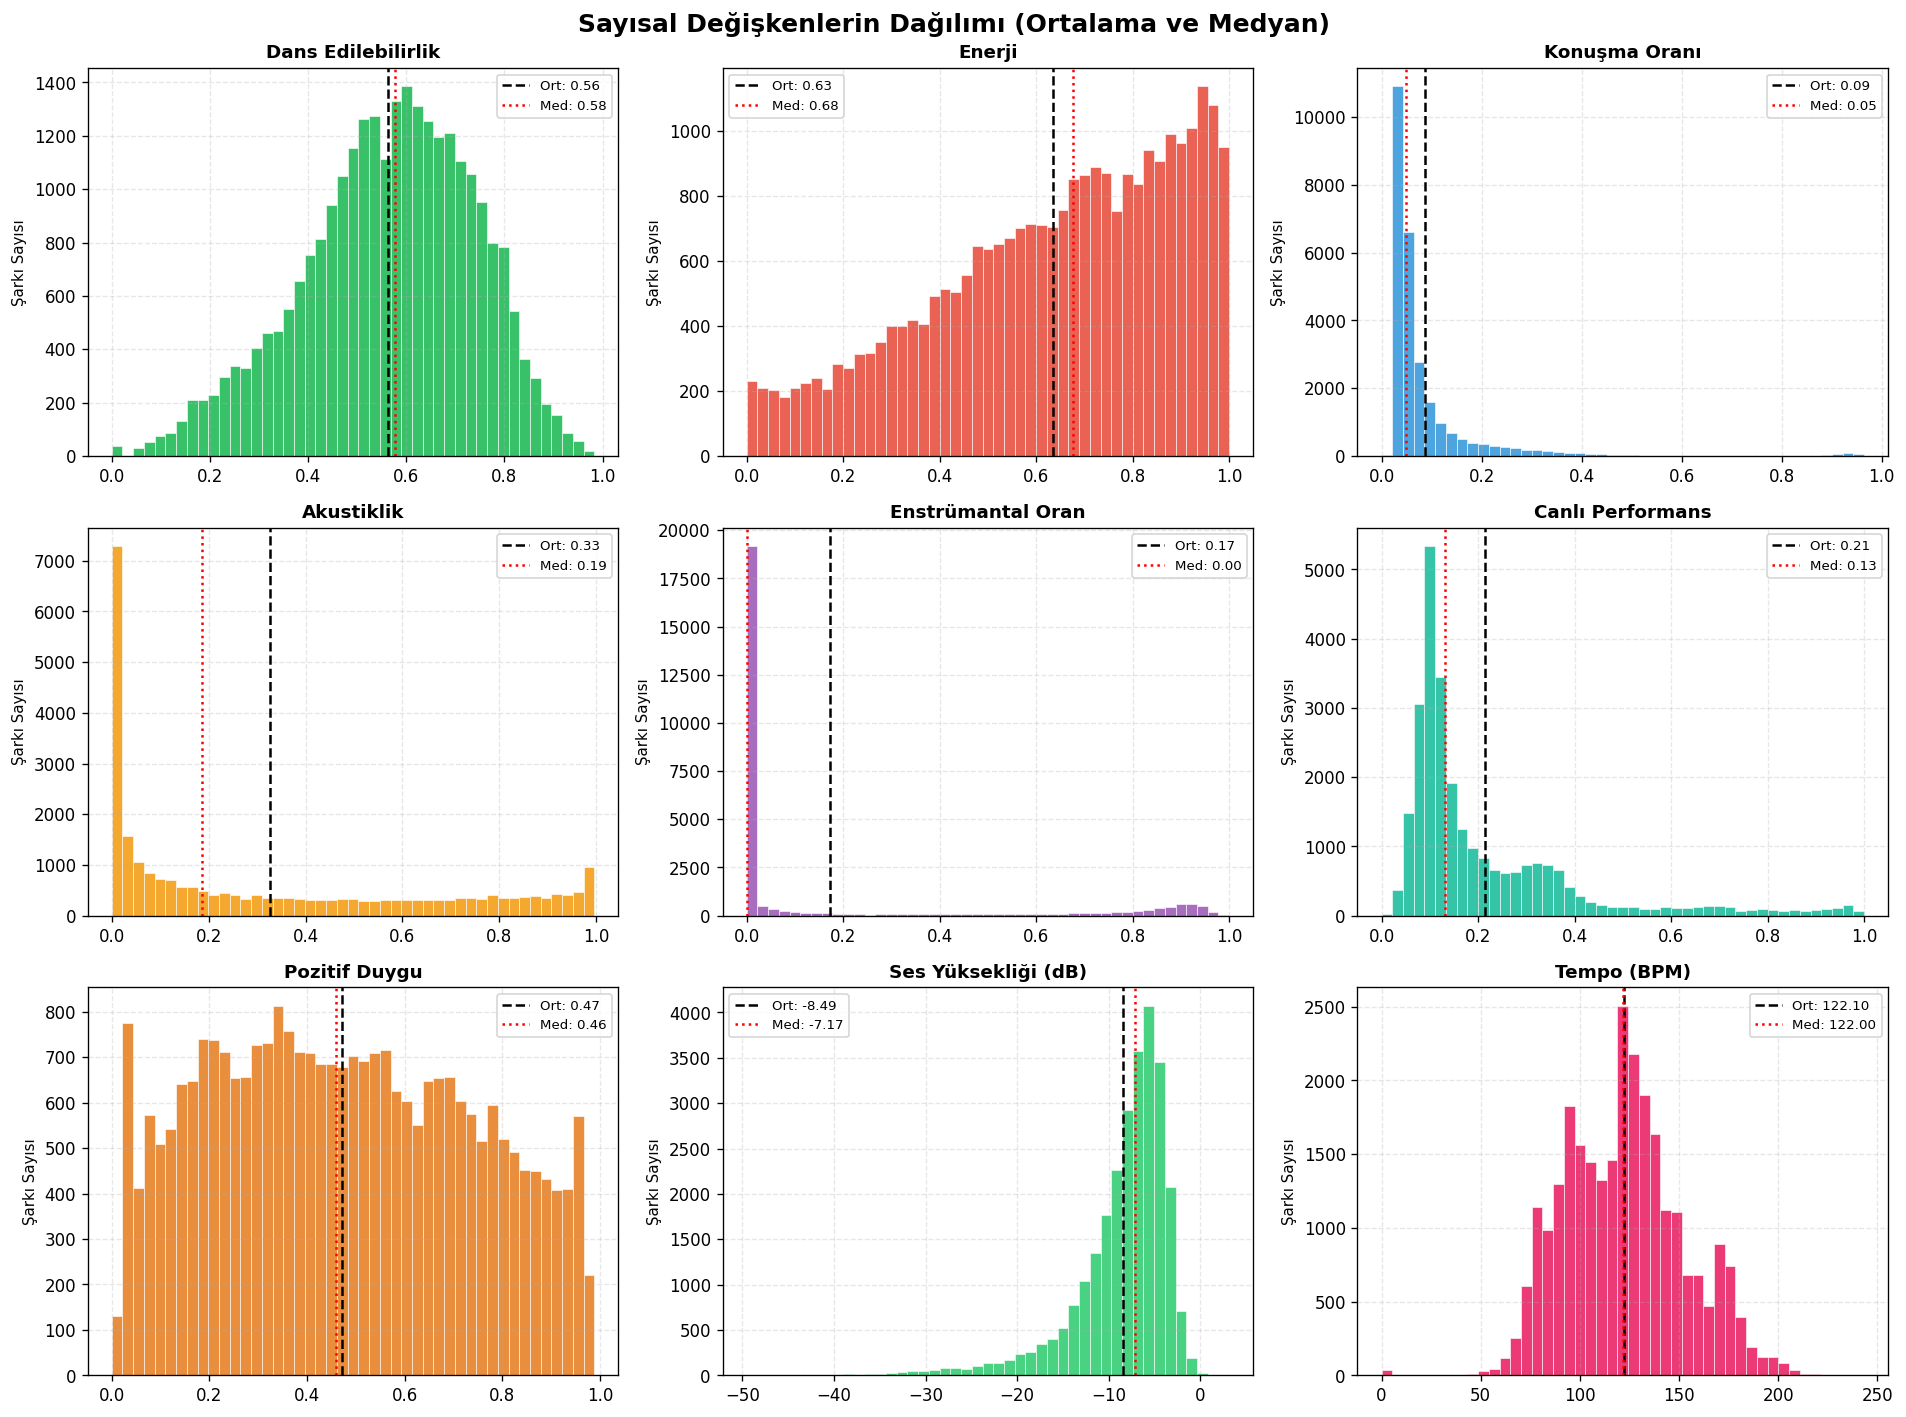

In [19]:
hist_kolonlar = ['danceability', 'energy', 'speechiness', 'acousticness', 
                 'instrumentalness', 'liveness', 'valence', 'loudness', 'tempo']

renkler = ['#1DB954', '#E74C3C', '#3498DB', '#F39C12', 
           '#9B59B6', '#1ABC9C', '#E67E22', '#2ECC71', '#E91E63']

hist_tr = {
    'danceability': 'Dans Edilebilirlik',
    'energy': 'Enerji',
    'speechiness': 'Konuşma Oranı',
    'acousticness': 'Akustiklik',
    'instrumentalness': 'Enstrümantal Oran',
    'liveness': 'Canlı Performans',
    'valence': 'Pozitif Duygu',
    'loudness': 'Ses Yüksekliği (dB)',
    'tempo': 'Tempo (BPM)'
}

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, (kolon, renk) in enumerate(zip(hist_kolonlar, renkler)):
    data = sample_pd[kolon].dropna()
    axes[i].hist(data, bins=45, color=renk,
                 edgecolor='white', linewidth=0.4, alpha=0.88)
    ort = data.mean()
    med = data.median()
    axes[i].axvline(ort, color='black', linestyle='--',
                    linewidth=1.5, label=f'Ort: {ort:.2f}')
    axes[i].axvline(med, color='red', linestyle=':',
                    linewidth=1.5, label=f'Med: {med:.2f}')
    axes[i].set_title(hist_tr[kolon], fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Şarkı Sayısı', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, linestyle='--', alpha=0.3)


plt.suptitle('Sayısal Değişkenlerin Dağılımı (Ortalama ve Medyan)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Çıkarım:** Dans edilebilirlik (danceability) ve pozitif duygu (valence) normale yakın simetrik dağılım sergilerken enerji (energy) sola çarpık olup yüksek değerlerde yoğunlaşmaktadır. Konuşma oranı (speechiness) ve enstrümantal oran (instrumentalness) sıfıra yakın değerlerde aşırı yoğunlaşmakta. Akustiklik (acousticness) de benzer şekilde düşük değerlerde yoğunlaşmaktadır. Ses yüksekliği (loudness) -10 ile 0 dB arasında yoğunlaşırken sola uzanan kuyruk aykırı değerlerin varlığını doğrulamaktadır. Tempo ise 100-130 arasında çift tepeli bir dağılım göstermekte olup bu durum farklı müzik türlerinin tempo alışkanlıklarını yansıtmakta.

Histogramlar incelendiğinde dans edilebilirlik ve pozitif duygu değerlerinin dengeli dağıldığı, enerji değerlerinin ise yüksek tarafta toplandığı görülmektedir. Konuşma oranı, enstrümantal oran ve akustiklik değerlerinin büyük çoğunluğu sıfıra yakın bir noktada yığılmış olup bu değişkenlerin model için dönüştürülmesi gerekebilir. 

#### 7. Adım — Korelasyon Isı Haritasının Görselleştirilmesi

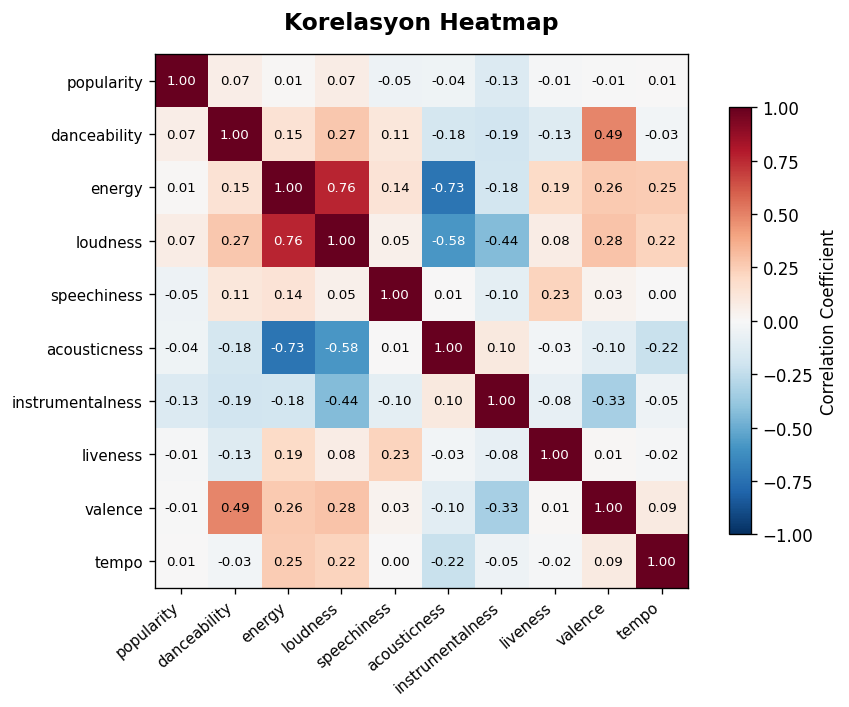

In [20]:
corr_kolonlar = [
    'popularity', 'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo'
]

corr_pd = df.select(corr_kolonlar) \
            .sample(fraction=0.3, seed=42) \
            .toPandas()
corr_matrix = corr_pd.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Correlation Coefficient', fontsize=10)

ax.set_xticks(range(len(corr_kolonlar)))
ax.set_yticks(range(len(corr_kolonlar)))
ax.set_xticklabels(corr_kolonlar, rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(corr_kolonlar, fontsize=9)

for i in range(len(corr_kolonlar)):
    for j in range(len(corr_kolonlar)):
        val = corr_matrix.values[i, j]
        tc = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color=tc)

ax.set_title('Korelasyon Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Çıkarım:** En güçlü pozitif korelasyon energy ile loudness arasında (0.76) gözlemlenirken acousticness ile energy (-0.73) ve acousticness ile loudness (-0.58) arasında güçlü negatif korelasyon bulunmaktadır; akustik şarkıların daha düşük enerjili ve sessiz olduğu anlaşılmakta. danceability ile valence arasında orta düzeyde pozitif korelasyon (0.50) mevcuttur. popularity ile hiçbir değişken arasında güçlü korelasyon bulunmaması, popülerlik tahmininin birden fazla özelliğin birlikte modellenmesini gerektirdiğini ortaya koymaktadır.

#### 8. Adım — Scatter Plot

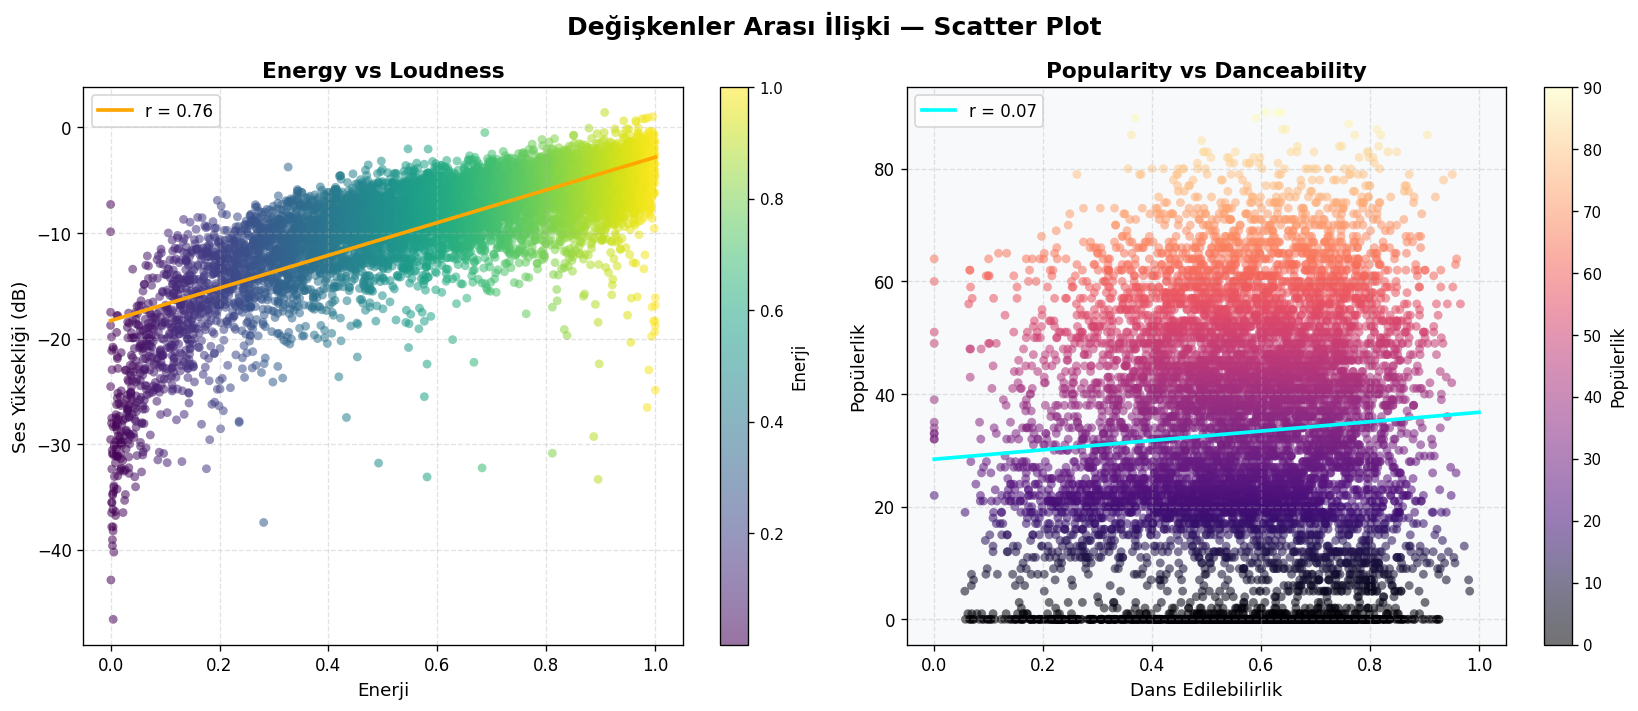

In [21]:
sc_pd = df.select('energy', 'loudness', 'danceability', 'popularity') \
          .sample(fraction=0.1, seed=42) \
          .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# energy- loudness
sc1 = axes[0].scatter(
    sc_pd['energy'], sc_pd['loudness'],
    c=sc_pd['energy'], cmap='viridis',
    alpha=0.55, s=28, edgecolors='none'
)
z1 = np.polyfit(sc_pd['energy'].fillna(0),
                sc_pd['loudness'].fillna(0), 1)
x1 = np.linspace(0, 1, 100)
r1 = sc_pd[['energy','loudness']].corr().iloc[0,1]
axes[0].plot(x1, np.poly1d(z1)(x1), 'orange', linewidth=2.2,
             label=f'r = {r1:.2f}')
axes[0].set_title('Energy vs Loudness', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Enerji', fontsize=11)
axes[0].set_ylabel('Ses Yüksekliği (dB)', fontsize=11)
axes[0].legend(fontsize=10, loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.35)
cbar1 = plt.colorbar(sc1, ax=axes[0], label='Enerji')
cbar1.ax.tick_params(labelsize=9)

#popularity-danceability
sc2 = axes[1].scatter(
    sc_pd['danceability'], sc_pd['popularity'],
    c=sc_pd['popularity'], cmap='magma',
    alpha=0.55, s=28, edgecolors='none'
)
z2 = np.polyfit(sc_pd['danceability'].fillna(0),
                sc_pd['popularity'].fillna(0), 1)
x2 = np.linspace(0, 1, 100)
r2 = sc_pd[['danceability','popularity']].corr().iloc[0,1]
axes[1].plot(x2, np.poly1d(z2)(x2), 'cyan', linewidth=2.2,
             label=f'r = {r2:.2f}')
axes[1].set_facecolor('#f8f9fa')
axes[1].set_title('Popularity vs Danceability',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Dans Edilebilirlik', fontsize=11)
axes[1].set_ylabel('Popülerlik', fontsize=11)
axes[1].legend(fontsize=10, loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.35)
cbar2 = plt.colorbar(sc2, ax=axes[1], label='Popülerlik')
cbar2.ax.tick_params(labelsize=9)

plt.suptitle('Değişkenler Arası İlişki — Scatter Plot',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Çıkarım:** Energy ile loudness arasında güçlü pozitif ilişki (r=0.76) gözlemlenmektedir; enerjik şarkıların ses yüksekliğinin de arttığı görülmektedir. Buna karşın popularity ile danceability arasında çok zayıf bir ilişki (r=0.07) bulunmaktadır. Bu bulgu korelasyon heatmap sonuçlarını desteklemekte olup popülerlik tahmininin tek bir özelliğe değil, birden fazla değişkenin birlikte modellenmesine ihtiyaç duyduğunu göstermektedir.

#### 9.Adım — Kategorik Değişken Analizi

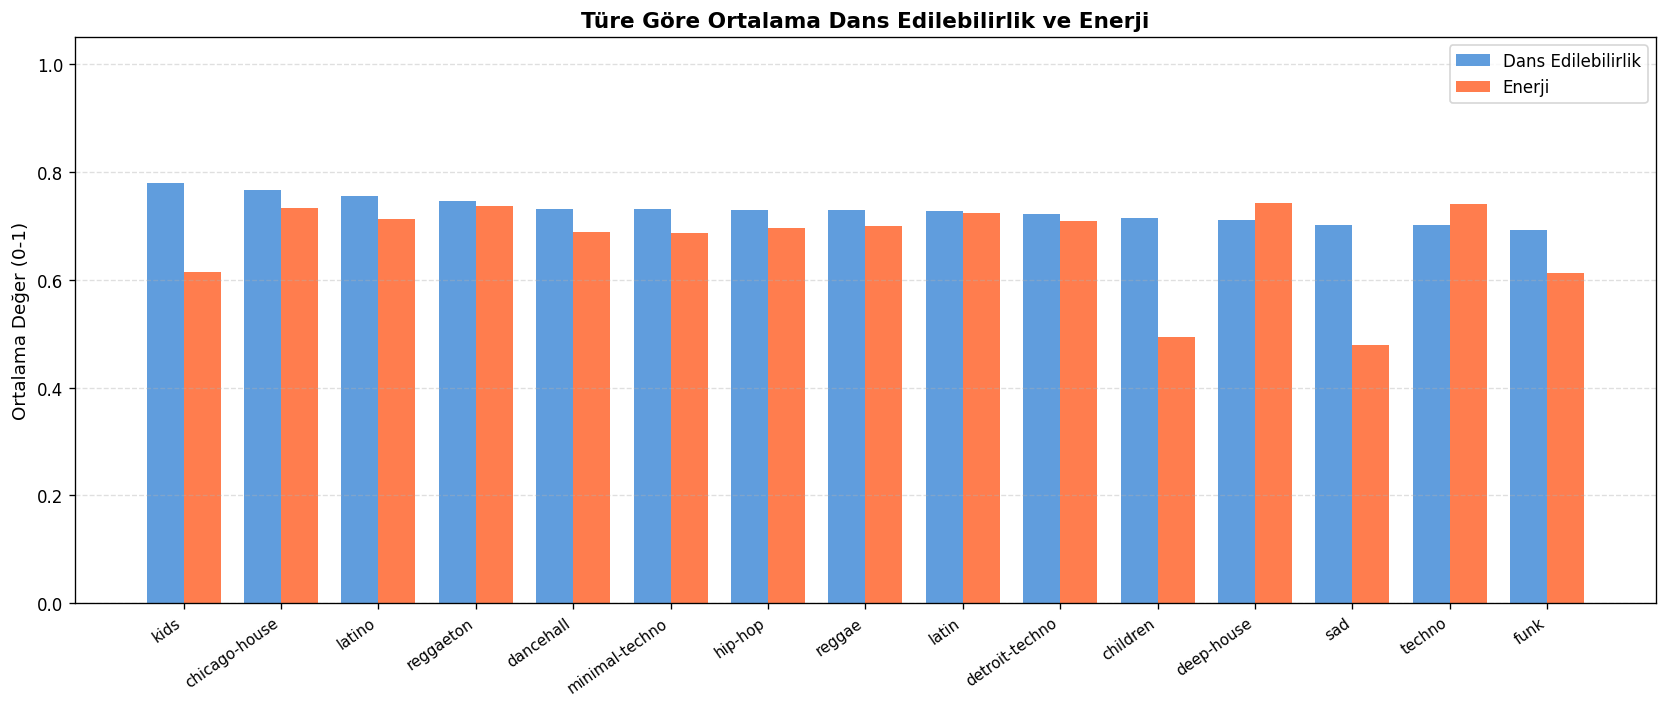

In [22]:
#Türe göre ortalama danceability ve energy
genre_avg = df.groupBy("track_genre") \
              .agg(
                  avg("danceability").alias("ort_dance"),
                  avg("energy").alias("ort_energy")
              ) \
              .orderBy(desc("ort_dance")) \
              .limit(15) \
              .toPandas()

x = np.arange(len(genre_avg))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, genre_avg['ort_dance'], w,
       label='Dans Edilebilirlik', color='#4A90D9', alpha=0.88) 
ax.bar(x + w/2, genre_avg['ort_energy'], w,
       label='Enerji', color='#FF6B35', alpha=0.88)            
ax.set_xticks(x)
ax.set_xticklabels(genre_avg['track_genre'],
                    rotation=35, ha='right', fontsize=9)
ax.set_title('Türe Göre Ortalama Dans Edilebilirlik ve Enerji',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Ortalama Değer (0-1)', fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Çıkarım**:Dans edilebilirlik açısından en yüksek değerlere kids, chicago-house ve latino türleri sahipken children ve sad türlerinde enerji belirgin şekilde düşük kalmaktadır. Genel olarak dans edilebilirliği yüksek türlerin enerji değerleri de yüksek seyretmekte olup bu iki özellik arasındaki pozitif ilişkiyi desteklemektedir. Bu bulgular tür tahmini için danceability ve energy'nin birlikte güçlü ayırt edici özellikler olduğunu ortaya koymaktadır.

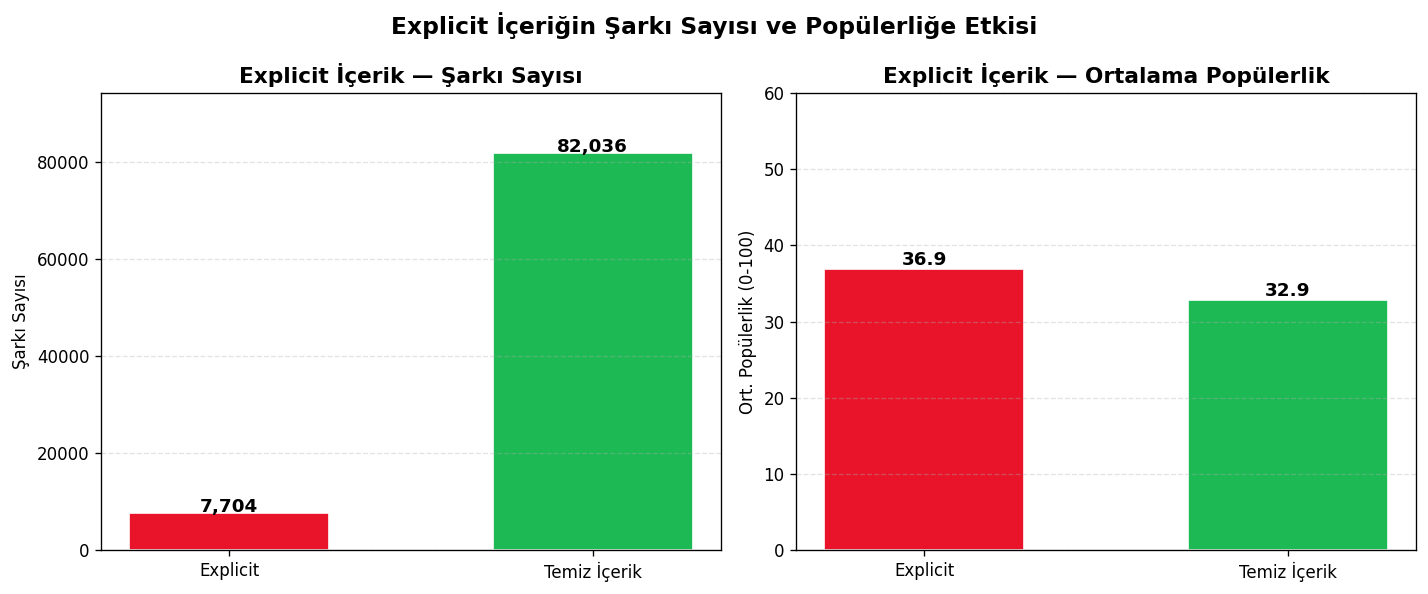

In [23]:
#Explicit içerik dağılımı ve popülerliğe etkisi
exp_pd = df.groupBy("explicit") \
           .agg(count("*").alias("adet"),
                avg("popularity").alias("ort_pop")) \
           .toPandas()

exp_pd['etiket'] = exp_pd['explicit'].map(
    {1: 'Explicit', 0: 'Temiz İçerik'}
)
renkler_e = ['#E91429' if e == 1 else '#1DB954'
             for e in exp_pd['explicit']]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

b1 = axes[0].bar(exp_pd['etiket'], exp_pd['adet'],
                  color=renkler_e, edgecolor='white', width=0.55)
for bar, val in zip(b1, exp_pd['adet']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 150,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Explicit İçerik — Şarkı Sayısı', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Şarkı Sayısı', fontsize=10)
axes[0].set_ylim(0, exp_pd['adet'].max() * 1.15)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.35)

b2 = axes[1].bar(exp_pd['etiket'], exp_pd['ort_pop'],
                  color=renkler_e, edgecolor='white', width=0.55)
for bar, val in zip(b2, exp_pd['ort_pop']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Explicit İçerik — Ortalama Popülerlik', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Ort. Popülerlik (0-100)', fontsize=10)
axes[1].set_ylim(0, 60)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.35)

plt.suptitle('Explicit İçeriğin Şarkı Sayısı ve Popülerliğe Etkisi',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Çıkarım:** Veri setinin büyük çoğunluğu (82,036 şarkı) temiz içerikten oluşurken explicit içerikli şarkı sayısı 7.704 ile oldukça düşük kalmaktadır. Buna karşın explicit şarkıların ortalama popülerliği (36.9) temiz içerikli şarkılara (32.9) kıyasla daha yüksektir. Bu bulgu explicit değişkeninin popülerlik tahmininde anlamlı bir katkı sağlayabileceğine işaret etmekte olup Feature Engineering adımında 0/1 binary özellik olarak modele dahil edilmeli.

#### 10. Adım - Her türün 5 ses özelliği üzerinden karşılaştırılması

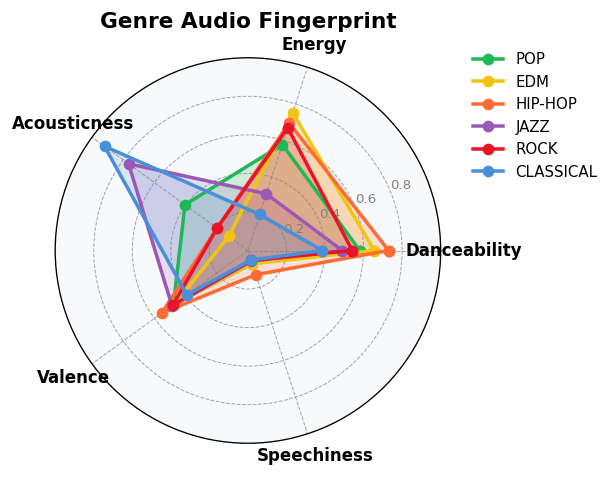

In [25]:
secili_turler = ['pop', 'rock', 'hip-hop', 'classical', 'jazz', 'edm']
radar_ozl = ['danceability', 'energy', 'acousticness', 'valence', 'speechiness']
radar_etiket = ['Danceability', 'Energy', 'Acousticness', 'Valence', 'Speechiness']

radar_pd = df.filter(col('track_genre').isin(secili_turler)) \
             .groupBy('track_genre') \
             .agg(*[avg(c).alias(c) for c in radar_ozl]) \
             .toPandas()

n = len(radar_ozl)
angles = [k * 2 * np.pi / n for k in range(n)] + [0]

tur_renk = {
    'pop': '#1DB954', 'rock': '#E91429',
    'hip-hop': '#FF6B35', 'classical': '#4A90D9',
    'jazz': '#9B59B6', 'edm': '#F1C40F'
}

fig, ax = plt.subplots(figsize=(5.2, 5.2), subplot_kw=dict(projection='polar'))
ax.set_facecolor('#f8f9fa')

for _, row in radar_pd.iterrows():
    tur = row['track_genre']
    degerler = [row[c] for c in radar_ozl] + [row[radar_ozl[0]]]
    renk = tur_renk.get(tur, '#888')
    ax.plot(angles, degerler, 'o-', linewidth=2.1, label=tur.upper(), color=renk)
    ax.fill(angles, degerler, alpha=0.18, color=renk)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_etiket, fontsize=10, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8'], fontsize=8, color='gray')
ax.grid(color='gray', linestyle='--', linewidth=0.6, alpha=0.7)
ax.set_title('Genre Audio Fingerprint', fontsize=13, fontweight='bold', pad=18)
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1.05), fontsize=9, frameon=False)
plt.tight_layout(pad=1.2)
plt.show()

**Çıkarım:** Analizde 113 türü temsilen 6 ana tür incelenmiştir. Her türün birbirinden belirgin şekilde ayrışan ses profili bulunmaktadır. Classical türü acousticness ekseninde açık ara öne çıkarken energy ve danceability değerleri düşük kalmaktadır. EDM ve Rock yüksek energy ile öne çıkmaktadır. Hip-hop speechiness ekseninde diğer türlerden belirgin şekilde ayrışmakta olup bu konuşma oranının tür tahmini için güçlü bir ayırt edici özellik olduğunu göstermektedir. Gözlemlere göre şarkı türleri için ses özelliklerinin sınıflandırma modelinde güçlü ayırt edici özellikler olabilir.

#### 11.Adım — Şarkı Sürelerinin Analizinin Yapılması
Hangi süredeki şarkıların daha popüler olduğu incelemesi yapıldı

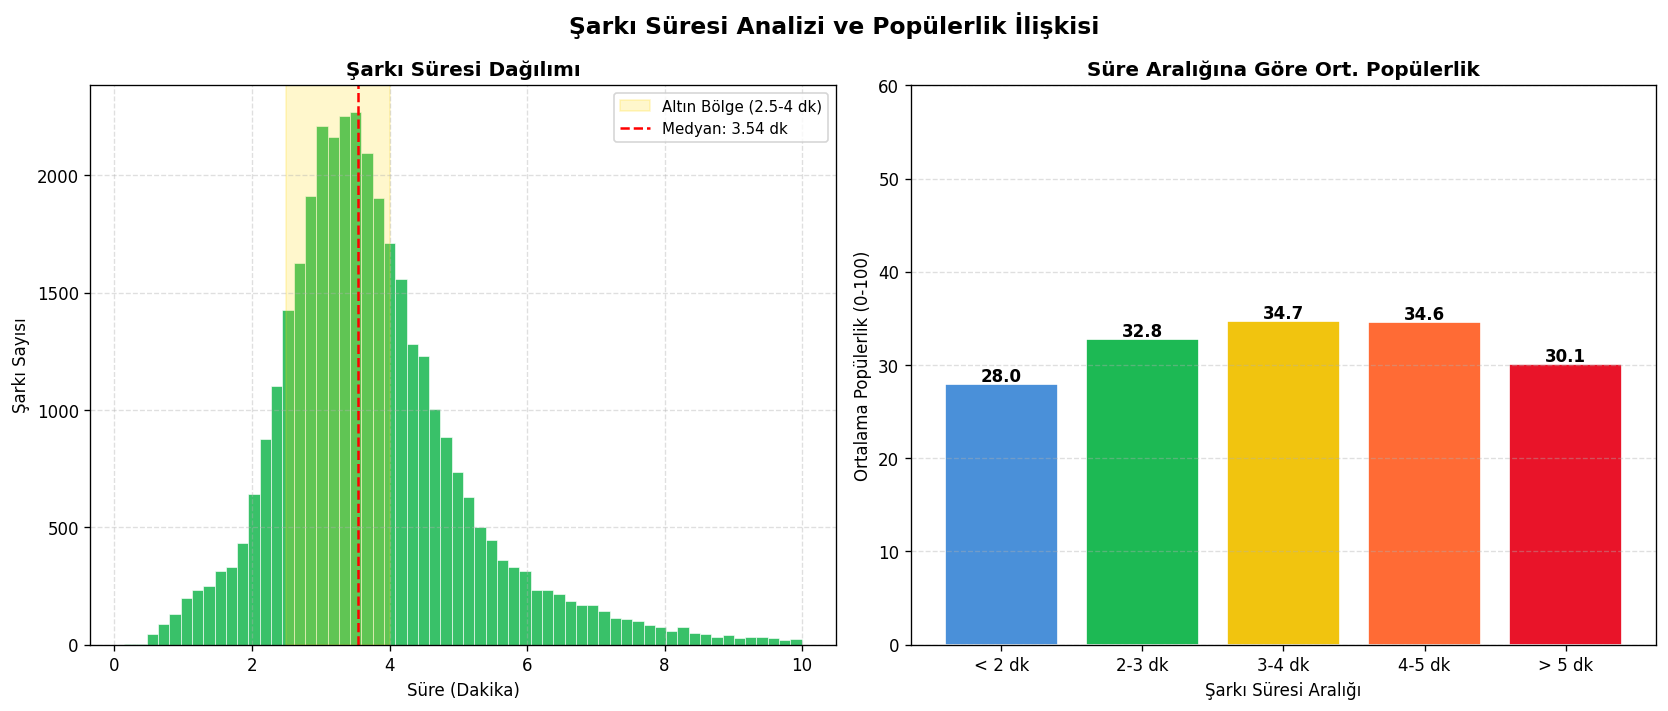

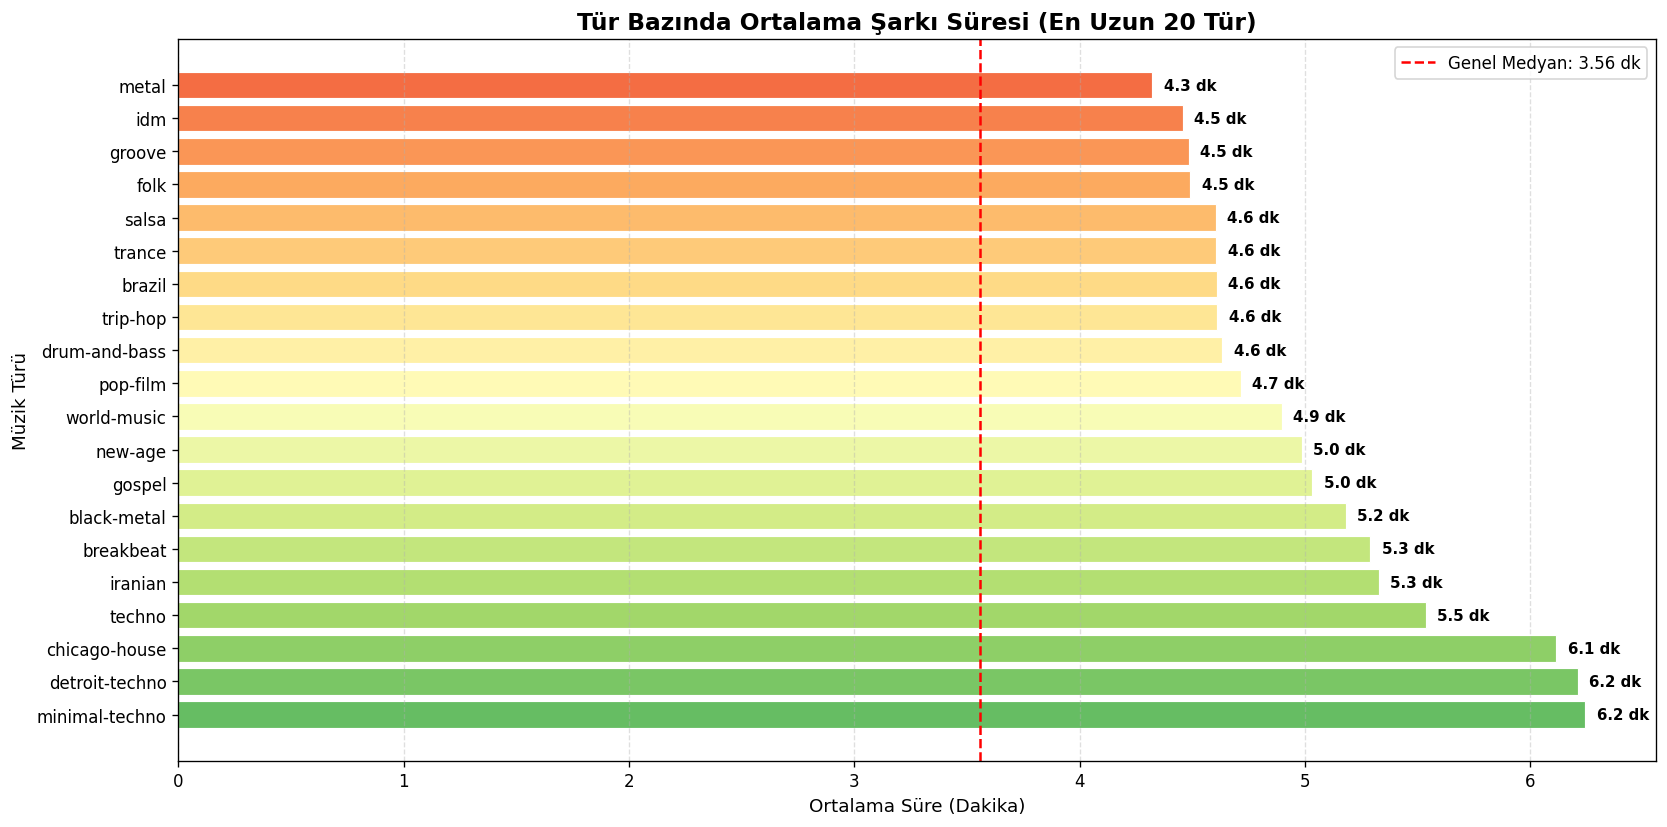

In [26]:
df_dur2 = df.withColumn("duration_min",
                         col("duration_ms") / 60000.0)

dur2_pd = df_dur2.filter(
    (col('duration_min') > 0) & (col('duration_min') < 10)
).select('duration_min', 'popularity') \
 .sample(fraction=0.4, seed=42) \
 .toPandas()

sure_sira = ['< 2 dk', '2-3 dk', '3-4 dk', '4-5 dk', '> 5 dk']
dur2_pd['sure_aralik'] = dur2_pd['duration_min'].apply(
    lambda x: '< 2 dk'  if x < 2 else
             ('2-3 dk'  if x < 3 else
             ('3-4 dk'  if x < 4 else
             ('4-5 dk'  if x < 5 else '> 5 dk')))
)
sure_pop = dur2_pd.groupby('sure_aralik')['popularity'] \
                   .mean().reindex(sure_sira)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(dur2_pd['duration_min'], bins=60,
             color='#1DB954', edgecolor='white',
             linewidth=0.4, alpha=0.88)
axes[0].axvspan(2.5, 4.0, alpha=0.2, color='gold',
                label='Altın Bölge (2.5-4 dk)')
axes[0].axvline(
    dur2_pd['duration_min'].median(),
    color='red', linestyle='--', linewidth=1.5,
    label=f'Medyan: {dur2_pd["duration_min"].median():.2f} dk'
)
axes[0].set_title('Şarkı Süresi Dağılımı', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Süre (Dakika)', fontsize=10)
axes[0].set_ylabel('Şarkı Sayısı', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.4)

renk_sure = ['#4A90D9','#1DB954','#F1C40F','#FF6B35','#E91429']
bars = axes[1].bar(sure_pop.index, sure_pop.values,
                   color=renk_sure, edgecolor='white')
for bar, val in zip(bars, sure_pop.values):
    if not np.isnan(val):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.3,
                     f'{val:.1f}', ha='center',
                     fontsize=10, fontweight='bold')
axes[1].set_title('Süre Aralığına Göre Ort. Popülerlik',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Şarkı Süresi Aralığı', fontsize=10)
axes[1].set_ylabel('Ortalama Popülerlik (0-100)', fontsize=10)
axes[1].set_ylim(0, 60)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Şarkı Süresi Analizi ve Popülerlik İlişkisi',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# Tür bazında ortalama şarkı süresi
tur_sure_pd = df.withColumn("sure_dakika", col("duration_ms") / 60000) \
                .groupBy("track_genre") \
                .agg(avg("sure_dakika").alias("ort_sure_dk")) \
                .orderBy(col("ort_sure_dk").desc()) \
                .limit(20) \
                .toPandas()

fig, ax = plt.subplots(figsize=(14, 7))

colors = plt.cm.RdYlGn(np.linspace(0.8, 0.2, len(tur_sure_pd)))
bars = ax.barh(tur_sure_pd["track_genre"], tur_sure_pd["ort_sure_dk"],
               color=colors, edgecolor="white", linewidth=0.7)

for bar, val in zip(bars, tur_sure_pd["ort_sure_dk"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val:.1f} dk", va="center", fontsize=9, fontweight="bold")

ax.set_title("Tür Bazında Ortalama Şarkı Süresi (En Uzun 20 Tür)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Ortalama Süre (Dakika)", fontsize=11)
ax.set_ylabel("Müzik Türü", fontsize=11)
ax.grid(True, axis="x", linestyle="--", alpha=0.4)
ax.axvline(3.56, color="red", linestyle="--", linewidth=1.5,
           label="Genel Medyan: 3.56 dk")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Çıkarım:** Şarkıların büyük çoğunluğu 2.5-4 dakika aralığında yoğunlaşmakta olup medyan süre 3.55 dakikadır. Süre aralığına göre popülerlik incelendiğinde 3-4 dakika ve 4-5 dakika aralığındaki şarkıların en yüksek ortalama popülerliğe (34.7) sahip olduğu görülmektedir. 2 dakikanın altındaki kısa şarkılar en düşük popülerlik skoruna (28.0) sahipken 5 dakika üzeri şarkılarda da popülerlik düşmektedir. Bu durum, şarkı süresinin popülerlikle anlamlı bir ilişki içinde olduğuna işaret ediyor ve Feature Engineering adımında model eğitimlerinde attribute olarak verilmesi için süreye dayalı bir özellik türetilmesi gerektiği çıkarımı yapılmıştır.

#### 12. Adım — Tempo Gruplaması Analizi
Yavaş/Orta/Hızlı tempo gruplarının popülerlik ile ilişkisi

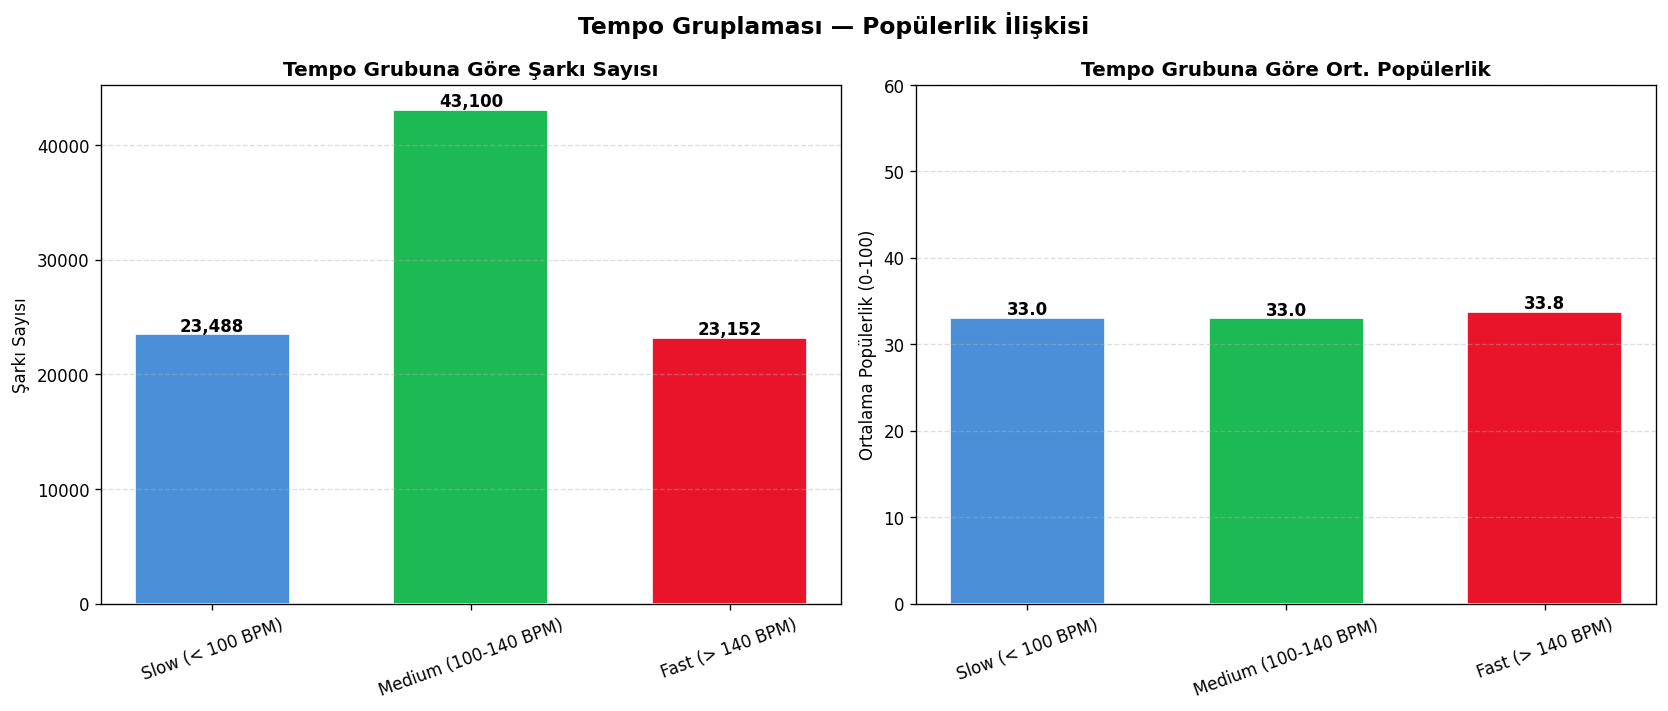

In [27]:
# Tempo grupları: Slow (< 100 BPM), Medium (100-140 BPM), Fast (> 140 BPM)
tempo_pd = df.select('tempo', 'popularity') \
             .filter(col('tempo').isNotNull()) \
             .toPandas()

tempo_pd['tempo_group'] = tempo_pd['tempo'].apply(
    lambda x: 'Slow (< 100 BPM)' if x < 100 else
             ('Medium (100-140 BPM)' if x <= 140 else 'Fast (> 140 BPM)')
)

tempo_grp_pop = tempo_pd.groupby('tempo_group')['popularity'].mean()
tempo_grp_cnt = tempo_pd.groupby('tempo_group').size()

grp_order = ['Slow (< 100 BPM)', 'Medium (100-140 BPM)', 'Fast (> 140 BPM)']
tempo_grp_pop = tempo_grp_pop.reindex(grp_order)
tempo_grp_cnt = tempo_grp_cnt.reindex(grp_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
renk_tempo = ['#4A90D9', '#1DB954', '#E91429']

# Sol: Şarkı sayısı
bars1 = axes[0].bar(grp_order, tempo_grp_cnt.values,
                    color=renk_tempo, edgecolor='white', width=0.6)
for bar, val in zip(bars1, tempo_grp_cnt.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 300,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Tempo Grubuna Göre Şarkı Sayısı',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Şarkı Sayısı', fontsize=10)
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.4)

# Sağ: Ortalama popülerlik
bars2 = axes[1].bar(grp_order, tempo_grp_pop.values,
                    color=renk_tempo, edgecolor='white', width=0.6)
for bar, val in zip(bars2, tempo_grp_pop.values):
    if not np.isnan(val):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.4,
                     f'{val:.1f}', ha='center',
                     fontweight='bold', fontsize=10)
axes[1].set_title('Tempo Grubuna Göre Ort. Popülerlik',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Ortalama Popülerlik (0-100)', fontsize=10)
axes[1].set_ylim(0, 60)
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Tempo Gruplaması — Popülerlik İlişkisi',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Çıkarım:** Şarkıların yarısından fazlası (43.100) medium tempo aralığında (100-140 BPM) yer alırken slow ve fast grupları birbirine yakın sayıda şarkı içermektedir. Popülerlik açısından tempo grupları arasında belirgin bir fark gözlemlenmemekte olup üç grubun ortalama popülerliği birbirine çok yakındır (33.0, 33.0, 33.8). Bu durum temponun tek başına popülerliği belirleyen bir faktör olmadığını göstermektedir. Buna karşın tempo grupları tür tahmini açısından anlamlı olabilir ve Feature Engineering adımında tempo_category özelliği olarak modele eklenebilir.

#### 13.Adım — Koşullu Dağılım Analizi
Popüler ve popüler olmayan şarkıların farkları neler

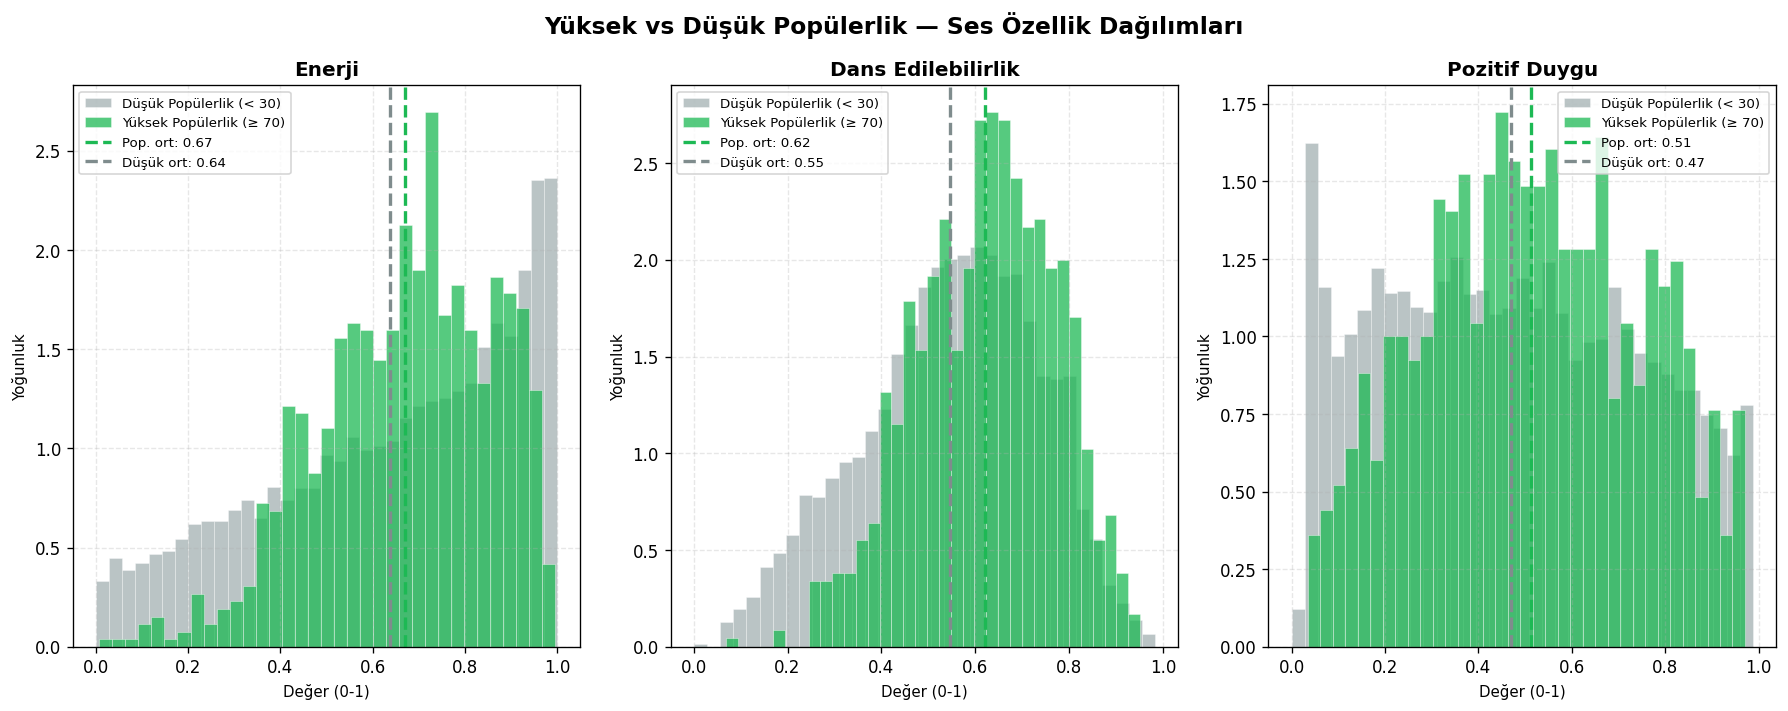

In [28]:
cond_pd = df.select('popularity', 'energy',
                    'danceability', 'valence') \
            .sample(fraction=0.3, seed=42) \
            .toPandas()

populer   = cond_pd[cond_pd['popularity'] >= 70]
dusuk_pop = cond_pd[cond_pd['popularity'] < 30]

ozellikler = ['energy', 'danceability', 'valence']
ozlk_tr    = ['Enerji', 'Dans Edilebilirlik', 'Pozitif Duygu']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, (ozl, isim) in enumerate(zip(ozellikler, ozlk_tr)):
    axes[i].hist(dusuk_pop[ozl].dropna(), bins=35,
                 color='#95A5A6', alpha=0.65,
                 label='Düşük Popülerlik (< 30)',
                 density=True, edgecolor='white', linewidth=0.3)
    axes[i].hist(populer[ozl].dropna(), bins=35,
                 color='#1DB954', alpha=0.75,
                 label='Yüksek Popülerlik (≥ 70)',
                 density=True, edgecolor='white', linewidth=0.3)
    m1 = populer[ozl].mean()
    m2 = dusuk_pop[ozl].mean()
    axes[i].axvline(m1, color='#1DB954', linestyle='--',
                    linewidth=2, label=f'Pop. ort: {m1:.2f}')
    axes[i].axvline(m2, color='#7F8C8D', linestyle='--',
                    linewidth=2, label=f'Düşük ort: {m2:.2f}')
    axes[i].set_title(isim, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Değer (0-1)', fontsize=9)
    axes[i].set_ylabel('Yoğunluk', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Yüksek vs Düşük Popülerlik — Ses Özellik Dağılımları',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Çıkarım:** Yüksek popülerlikli şarkılar ile düşük popülerlikli şarkılar karşılaştırıldığında energy, danceability ve valence değerlerinin yüksek popülerlikli şarkılarda daha yüksek olduğu görülmektedir. Enerji ortalaması yüksek popülerde 0.67, düşük popülerde 0.64; dans edilebilirlik 0.62 ve 0.55; pozitif duygu 0.51 ve 0.47 olarak ölçülmüştür. Farklar küçük görünse de bu üç özelliğin popülerlikle pozitif yönde ilişkili olduğu gözlemlenmekte olup bu özellikler Feature Engineering adımında modele dahil edilebilir.

#### 14.Adım — Tür Bazında Popülerliklerin Box Plot Üzerinde Görselleştirilmesi

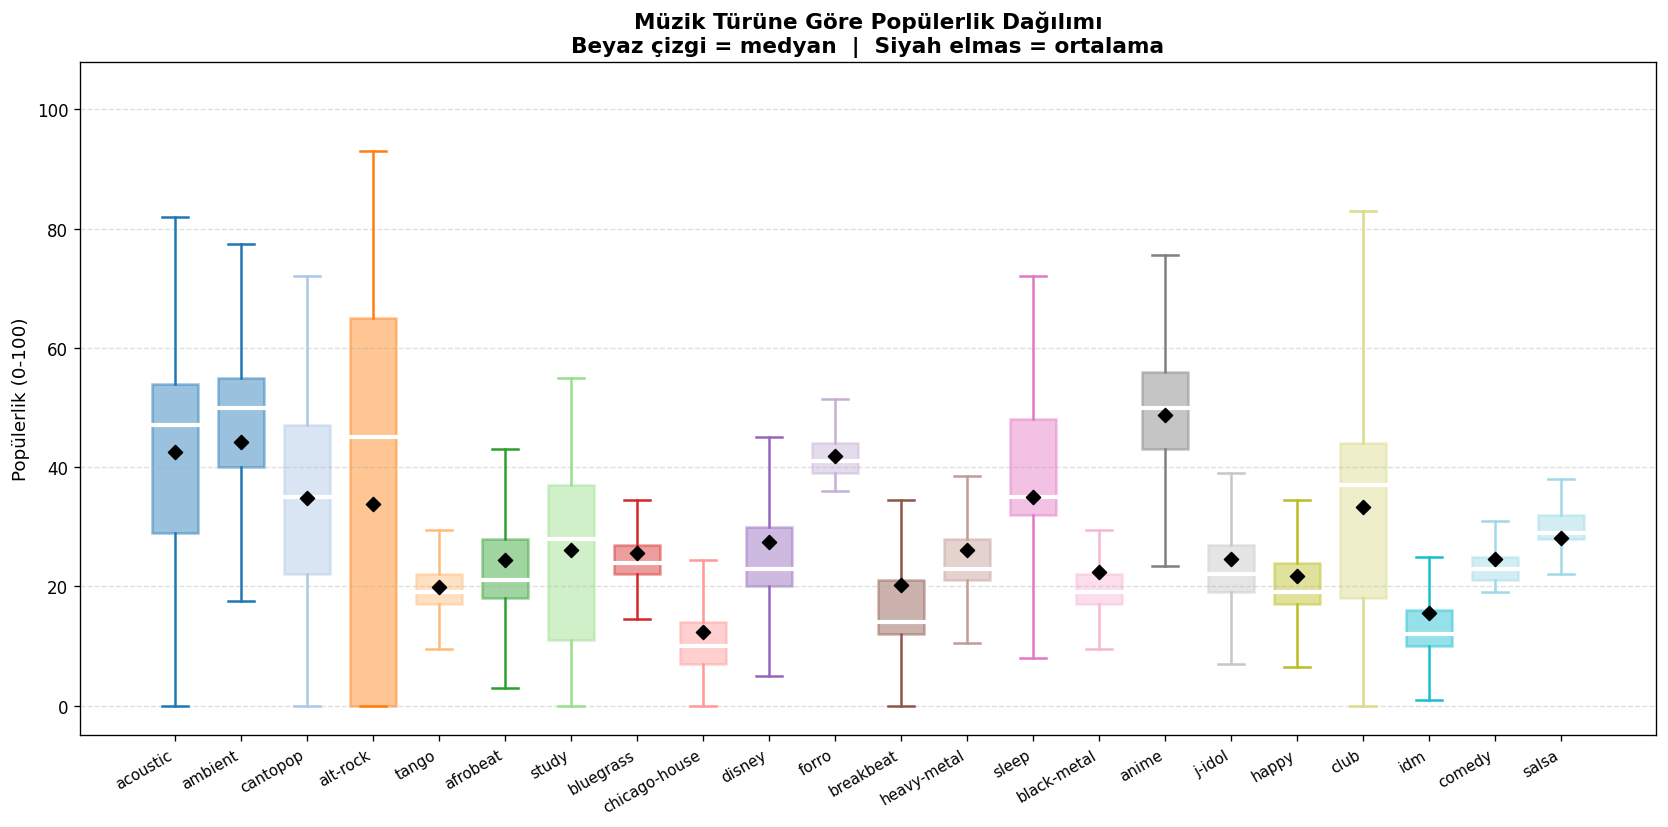

In [29]:
top12 = [r['track_genre'] for r in
         df.groupBy('track_genre').count()
           .orderBy(desc('count')).limit(22).collect()]

bp_data = {}
for tur in top12:
    s = df.filter(col('track_genre') == tur) \
          .agg(
              percentile_approx('popularity', 0.25).alias('q1'),
              percentile_approx('popularity', 0.50).alias('med'),
              percentile_approx('popularity', 0.75).alias('q3'),
              spark_min('popularity').alias('mn'),
              spark_max('popularity').alias('mx'),
              avg('popularity').alias('mean')
          ).collect()[0]
    bp_data[tur] = s.asDict()

fig, ax = plt.subplots(figsize=(14, 7))
tur_renk = plt.cm.tab20(np.linspace(0, 1, len(top12)))

for i, tur in enumerate(top12):
    s   = bp_data[tur]
    q1, med, q3 = s['q1'], s['med'], s['q3']
    iqr = q3 - q1
    lf  = max(s['mn'], q1 - 1.5 * iqr)
    uf  = min(s['mx'], q3 + 1.5 * iqr)
    rc  = tur_renk[i]

    ax.plot([i+1]*2, [lf, q1],  color=rc, linewidth=1.5)
    ax.plot([i+1]*2, [q3, uf],  color=rc, linewidth=1.5)
    ax.plot([i+0.8, i+1.2], [lf, lf], color=rc, linewidth=1.5)
    ax.plot([i+0.8, i+1.2], [uf, uf], color=rc, linewidth=1.5)
    rect = plt.Rectangle((i+0.65, q1), 0.7, iqr,
                          facecolor=rc, alpha=0.45,
                          edgecolor=rc, linewidth=1.5)
    ax.add_patch(rect)
    ax.plot([i+0.65, i+1.35], [med, med],
            color='white', linewidth=2.5, zorder=5)
    ax.scatter([i+1], [s['mean']], color='black',
               zorder=6, s=35, marker='D')

ax.set_xticks(range(1, len(top12)+1))
ax.set_xticklabels(top12, rotation=30, ha='right', fontsize=9)
ax.set_title(
    'Müzik Türüne Göre Popülerlik Dağılımı\n'
    'Beyaz çizgi = medyan  |  Siyah elmas = ortalama',
    fontsize=13, fontweight='bold'
)
ax.set_ylabel('Popülerlik (0-100)', fontsize=11)
ax.set_ylim(-5, 108)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Çıkarım:** Grafik incelendiğinde türlerin popülerlik açısından birbirinden oldukça farklı davrandığı görülmektedir. Örneğin ambient ve anime türleri genel olarak daha popüler şarkılar içerirken breakbeat ve idm türlerindeki şarkılar düşük popülerlik skorlarına sahiptir. alt-rock'ta ise hem çok popüler hem de hiç popüler olmayan şarkılar bir arada bulunmaktadır.şarkının türü popülerliğini tahmin etmede işe yarayabilir.

In [ ]:
spark.stop()
print("Spark oturumu kapatıldı.")